In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from scipy.stats import jarque_bera, skew, kurtosis
import numexpr as ne
import numba
from numba import jit, prange
import joblib
from joblib import Parallel, delayed
import os
import time

# --- display config ---
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# --- global constants (from paper) ---
SIGMA_TAR  = 0.12       # annualized target volatility (12%), paper Section 4.2
RPM_WINDOW = 126        # 126 trading day lookback for partial moments, eq. (4)(5)
SCALE      = 21 / 126   # converts daily-sum to monthly variance units
FORM_START = 12         # formation period: t-12
FORM_END   = 2          # formation period: t-2  (skip t-1 to avoid reversal)
MAX_LEV    = 2.0        # 200% leverage cap for PMMC, paper Section 4.2
CACHE_DIR  = r'C:\Users\User\Documents\pmm\cache'
os.makedirs(CACHE_DIR, exist_ok=True)

print(f"numpy      : {np.__version__}")
print(f"pandas     : {pd.__version__}")
print(f"numba      : {numba.__version__}")
print(f"numexpr    : {ne.__version__}")
print(f"joblib     : {joblib.__version__}")
print(f"numexpr threads : {ne.detect_number_of_cores()} cores detected")
print(f"numba threads   : {numba.get_num_threads()} threads")
print()
print("--- Strategy constants ---")
print(f"  SIGMA_TAR  = {SIGMA_TAR}  (12% annualized target vol)")
print(f"  RPM_WINDOW = {RPM_WINDOW} trading days (~6 months)")
print(f"  SCALE      = {SCALE:.6f}  (21/126 monthly scaler, eq.4-5)")
print(f"  FORM       = t-{FORM_START} to t-{FORM_END}  (11-month formation, skip t-1)")
print(f"  MAX_LEV    = {MAX_LEV}  (200% cap for PMMC)")
print(f"  CACHE_DIR  = {CACHE_DIR}")


numpy      : 2.3.5
pandas     : 2.3.3
numba      : 0.62.1
numexpr    : 2.14.1
joblib     : 1.5.2
numexpr threads : 16 cores detected
numba threads   : 16 threads

--- Strategy constants ---
  SIGMA_TAR  = 0.12  (12% annualized target vol)
  RPM_WINDOW = 126 trading days (~6 months)
  SCALE      = 0.166667  (21/126 monthly scaler, eq.4-5)
  FORM       = t-12 to t-2  (11-month formation, skip t-1)
  MAX_LEV    = 2.0  (200% cap for PMMC)
  CACHE_DIR  = C:\Users\User\Documents\pmm\cache


In [2]:

# =============================================================================
# CELL 2 — Data Download
# All data from Kenneth R. French Data Library via pandas_datareader.
# We cache to parquet so we never re-download unless forced.
#
# Datasets:
#   mom10_monthly : 10 momentum decile portfolios (monthly %) — winners/losers
#   ff_daily      : Fama-French daily factors — we need Mkt-RF + RF for RPM
#   ff_monthly    : Fama-French monthly factors — RF, MKT, SMB, HML
#   ff5_monthly   : FF 5-factor monthly — adds RMW, CMA for spanning tests
# =============================================================================

def _cache_path(name):
    return os.path.join(CACHE_DIR, f"{name}.parquet")

def download_or_load(name, reader_fn):
    """Load from parquet cache if exists, else download and cache."""
    path = _cache_path(name)
    if os.path.exists(path):
        print(f"  [cache] {name}")
        return pd.read_parquet(path)
    print(f"  [download] {name} ...")
    t0 = time.time()
    df = reader_fn()
    df.to_parquet(path)
    print(f"           done in {time.time()-t0:.1f}s, shape={df.shape}")
    return df

# --- 10 momentum decile portfolios (monthly, value-weighted) ---
# P1 = losers (worst prior 12-2 return), P10 = winners
# French library name: '10_Portfolios_Prior_12_2'
mom10_monthly = download_or_load(
    'mom10_monthly',
    lambda: web.DataReader('10_Portfolios_Prior_12_2', 'famafrench', start='1926-01-01')[0]
)

# --- Fama-French daily factors: gives us Mkt-RF and RF at daily frequency ---
# Used to compute RPM+ and RPM- (need daily market returns, eq. 4 & 5)
ff_daily = download_or_load(
    'ff_daily',
    lambda: web.DataReader('F-F_Research_Data_Factors_daily', 'famafrench', start='1926-01-01')[0]
)

# --- Fama-French 3-factor monthly: MKT-RF, SMB, HML, RF ---
ff_monthly = download_or_load(
    'ff_monthly',
    lambda: web.DataReader('F-F_Research_Data_Factors', 'famafrench', start='1926-01-01')[0]
)

# --- FF 5-factor monthly: adds RMW, CMA ---
ff5_monthly = download_or_load(
    'ff5_monthly',
    lambda: web.DataReader('F-F_Research_Data_5_Factors_2x3', 'famafrench', start='1963-01-01')[0]
)

print()
print("=== Data shapes and date ranges ===")
for name, df in [('mom10_monthly', mom10_monthly),
                 ('ff_daily',      ff_daily),
                 ('ff_monthly',    ff_monthly),
                 ('ff5_monthly',   ff5_monthly)]:
    print(f"  {name:20s} shape={str(df.shape):15s} "
          f"index={df.index[0]} -> {df.index[-1]}  dtype={df.index.dtype}")

print()
print("=== mom10_monthly columns (decile portfolios) ===")
print(list(mom10_monthly.columns))
print()
print("=== ff_daily columns ===")
print(list(ff_daily.columns))
print()
print("=== ff_monthly columns ===")
print(list(ff_monthly.columns))


  [cache] mom10_monthly
  [cache] ff_daily
  [cache] ff_monthly
  [cache] ff5_monthly

=== Data shapes and date ranges ===
  mom10_monthly        shape=(1190, 10)      index=1927-01 -> 2026-02  dtype=period[M]
  ff_daily             shape=(26190, 4)      index=1926-07-01 00:00:00 -> 2026-02-27 00:00:00  dtype=datetime64[ns]
  ff_monthly           shape=(1196, 4)       index=1926-07 -> 2026-02  dtype=period[M]
  ff5_monthly          shape=(752, 6)        index=1963-07 -> 2026-02  dtype=period[M]

=== mom10_monthly columns (decile portfolios) ===
['Lo PRIOR', 'PRIOR 2', 'PRIOR 3', 'PRIOR 4', 'PRIOR 5', 'PRIOR 6', 'PRIOR 7', 'PRIOR 8', 'PRIOR 9', 'Hi PRIOR']

=== ff_daily columns ===
['Mkt-RF', 'SMB', 'HML', 'RF']

=== ff_monthly columns ===
['Mkt-RF', 'SMB', 'HML', 'RF']


In [3]:

# =============================================================================
# CELL: Logger utility
# Writes a compact state log after each cell so we can look up variable
# shapes/dtypes/ranges without loading data into memory.
# Log file: C:\Users\User\Documents\pmm\cell_state_log.md
# Usage in each cell (last line):
#   log_state("Cell N — description", {...})
# =============================================================================

import json
from datetime import datetime

LOG_PATH = r'C:\Users\User\Documents\pmm\cell_state_log.md'

def _fmt(val):
    """Convert a value to a concise loggable string."""
    if isinstance(val, pd.DataFrame):
        idx = val.index
        idx_info = f"{idx[0]} -> {idx[-1]}" if len(idx) > 0 else "empty"
        return {
            "type"    : "DataFrame",
            "shape"   : list(val.shape),
            "columns" : list(val.columns),
            "dtypes"  : {c: str(val[c].dtype) for c in val.columns},
            "index"   : str(idx.dtype),
            "range"   : idx_info,
            "nulls"   : int(val.isnull().sum().sum()),
        }
    elif isinstance(val, pd.Series):
        idx = val.index
        idx_info = f"{idx[0]} -> {idx[-1]}" if len(idx) > 0 else "empty"
        return {
            "type"  : "Series",
            "len"   : len(val),
            "dtype" : str(val.dtype),
            "range" : idx_info,
            "nulls" : int(val.isnull().sum()),
            "min"   : float(val.min()) if pd.api.types.is_numeric_dtype(val) else None,
            "max"   : float(val.max()) if pd.api.types.is_numeric_dtype(val) else None,
        }
    elif isinstance(val, np.ndarray):
        return {
            "type"  : "ndarray",
            "shape" : list(val.shape),
            "dtype" : str(val.dtype),
            "min"   : float(val.min()),
            "max"   : float(val.max()),
        }
    elif isinstance(val, dict):
        return {k: _fmt(v) for k, v in val.items()}
    else:
        return str(val)

def log_state(cell_label, state_dict):
    """
    Append a cell's state snapshot to the log file.
    cell_label : str  e.g. "Cell 2 — Data Download"
    state_dict : dict of variable_name -> variable (any type)
    """
    ts = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    lines = [f"\n## {cell_label}  [{ts}]\n```json"]
    formatted = {k: _fmt(v) for k, v in state_dict.items()}
    lines.append(json.dumps(formatted, indent=2))
    lines.append("```\n")
    entry = "\n".join(lines)

    with open(LOG_PATH, 'a', encoding='utf-8') as f:
        f.write(entry)

    print(f"[log] state written -> {LOG_PATH}  ({cell_label})")

# Initialize log file with header if it doesn't exist
if not os.path.exists(LOG_PATH):
    with open(LOG_PATH, 'w', encoding='utf-8') as f:
        f.write("# PMM Notebook — Cell State Log\n")
        f.write("Each cell appends its key variable shapes/dtypes/ranges here.\n")
        f.write("Never load this whole file — grep or extract specific sections.\n\n")
    print(f"[log] created {LOG_PATH}")
else:
    print(f"[log] log file exists: {LOG_PATH}")

# --- now log cell 2 state (backfill since logger didn't exist then) ---
log_state("Cell 2 — Data Download", {
    "mom10_monthly" : mom10_monthly,
    "ff_daily"      : ff_daily,
    "ff_monthly"    : ff_monthly,
    "ff5_monthly"   : ff5_monthly,
})


[log] log file exists: C:\Users\User\Documents\pmm\cell_state_log.md
[log] state written -> C:\Users\User\Documents\pmm\cell_state_log.md  (Cell 2 — Data Download)


Sample window : 1927-07 -> 2018-12
Months        : 1098
Columns       : ['Lo PRIOR', 'PRIOR 2', 'PRIOR 3', 'PRIOR 4', 'PRIOR 5', 'PRIOR 6', 'PRIOR 7', 'PRIOR 8', 'PRIOR 9', 'Hi PRIOR']
NaN count     : 0

=== Raw WML (Hi PRIOR - Lo PRIOR) ===
  Mean monthly return : 1.1879%
  Annualized return   : 14.25%   (paper Table 1: 14.98%)
  Annualized vol      : 27.05%
  Annualized SR       : 0.5271    (paper Table 1: 0.52)
  Skewness            : -2.3254  (paper: -2.33)
  Excess kurtosis     : 17.9474  (paper: 17.48)

=== Sample values (confirm % not decimal) ===
         Lo PRIOR  Hi PRIOR
Date                       
1927-07    4.1100   13.3300
1927-08   -0.5400    5.4800
1927-09   -0.3900    7.2900
1927-10   -6.0600   -6.0400
1927-11   13.6400    6.2100

=== 10 worst WML months (crash exposure) ===
  1932-08  -78.04%
  1932-07  -63.04%
  2009-04  -45.32%
  1939-09  -44.36%
  2001-01  -41.71%
  2009-03  -39.18%
  1938-06  -33.47%
  1933-04  -31.53%
  1933-05  -30.62%
  1931-06  -29.29%

=== 10

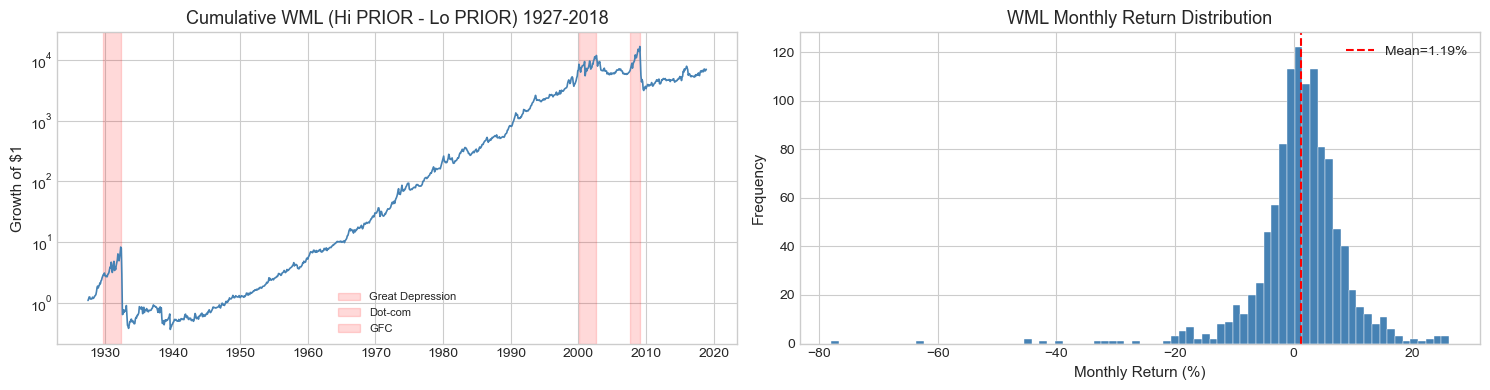

Plot saved: eda_wml.png
[log] state written -> C:\Users\User\Documents\pmm\cell_state_log.md  (Cell 4 — EDA Momentum Deciles)


In [4]:

# =============================================================================
# CELL 4 — EDA: Momentum Decile Portfolios
# Questions to answer:
#   1. What is the usable date range? (paper uses Jul 1927 - Dec 2018)
#   2. Are values in % or decimal? (French library returns %)
#   3. Distribution of Lo PRIOR vs Hi PRIOR — spread, skew
#   4. WML = Hi PRIOR - Lo PRIOR: does it match paper's ~14.98% ann. return?
#   5. Are there NaNs or data gaps?
#   6. Crash periods visible? (1932, 2000-02, 2008-09)
# =============================================================================

# --- 1. restrict to paper's sample window Jul 1927 - Dec 2018 ---
# mom10_monthly index is period[M], French data in percentage points
start = pd.Period('1927-07', freq='M')
end   = pd.Period('2018-12', freq='M')
mom  = mom10_monthly.loc[start:end].copy()

print(f"Sample window : {mom.index[0]} -> {mom.index[-1]}")
print(f"Months        : {len(mom)}")
print(f"Columns       : {list(mom.columns)}")
print(f"NaN count     : {mom.isnull().sum().sum()}")
print()

# --- 2. raw WML (winner minus loser) in percentage points ---
wml_raw = mom['Hi PRIOR'] - mom['Lo PRIOR']

# annualized stats
ann_ret   = wml_raw.mean() * 12
ann_vol   = wml_raw.std()  * np.sqrt(12)
ann_sr    = ann_ret / ann_vol
wml_skew  = skew(wml_raw.dropna())
wml_kurt  = kurtosis(wml_raw.dropna(), fisher=True)  # excess kurtosis

print("=== Raw WML (Hi PRIOR - Lo PRIOR) ===")
print(f"  Mean monthly return : {wml_raw.mean():.4f}%")
print(f"  Annualized return   : {ann_ret:.2f}%   (paper Table 1: 14.98%)")
print(f"  Annualized vol      : {ann_vol:.2f}%")
print(f"  Annualized SR       : {ann_sr:.4f}    (paper Table 1: 0.52)")
print(f"  Skewness            : {wml_skew:.4f}  (paper: -2.33)")
print(f"  Excess kurtosis     : {wml_kurt:.4f}  (paper: 17.48)")
print()

# --- 3. check data is in % (should see values like 1.2, -3.4, not 0.012) ---
print("=== Sample values (confirm % not decimal) ===")
print(mom[['Lo PRIOR','Hi PRIOR']].head(5))
print()

# --- 4. crash periods: worst WML months ---
print("=== 10 worst WML months (crash exposure) ===")
worst = wml_raw.nsmallest(10)
for dt, val in worst.items():
    print(f"  {dt}  {val:+.2f}%")
print()

# --- 5. best WML months ---
print("=== 10 best WML months ===")
best = wml_raw.nlargest(10)
for dt, val in best.items():
    print(f"  {dt}  {val:+.2f}%")
print()

# --- 6. decile spread plot ---
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# cumulative WML
cum_wml = (1 + wml_raw / 100).cumprod()
cum_wml.index = cum_wml.index.to_timestamp()
axes[0].plot(cum_wml.index, cum_wml.values, color='steelblue', lw=1.2)
axes[0].set_title('Cumulative WML (Hi PRIOR - Lo PRIOR) 1927-2018')
axes[0].set_ylabel('Growth of $1')
axes[0].set_yscale('log')
# shade key crash periods
for s, e_crash, label in [('1929-09','1932-06','Great Depression'),
                           ('2000-03','2002-09','Dot-com'),
                           ('2007-08','2009-03','GFC')]:
    axes[0].axvspan(pd.Timestamp(s), pd.Timestamp(e_crash), alpha=0.15, color='red', label=label)
axes[0].legend(fontsize=8)

# return distribution
axes[1].hist(wml_raw.dropna(), bins=80, color='steelblue', edgecolor='white', lw=0.3)
axes[1].axvline(wml_raw.mean(), color='red', lw=1.5, linestyle='--', label=f'Mean={wml_raw.mean():.2f}%')
axes[1].set_title('WML Monthly Return Distribution')
axes[1].set_xlabel('Monthly Return (%)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig(r'C:\Users\User\Documents\pmm\eda_wml.png', dpi=120, bbox_inches='tight')
plt.show()
print("Plot saved: eda_wml.png")

# --- log state ---
log_state("Cell 4 — EDA Momentum Deciles", {
    "mom"     : mom,
    "wml_raw" : wml_raw,
    "ann_ret_wml" : ann_ret,
    "ann_sr_wml"  : ann_sr,
})


Daily market returns: 1926-07-01 -> 2018-12-31
Observations        : 24,391
NaN count           : 0

=== Daily market return distribution ===
  Mean             : 0.0408%
  Std              : 1.0613%
  Skewness         : -0.1375  (negative = fat left tail)
  Excess kurtosis  : 16.3262

  # positive days  : 13,498 (55.3%)
  # negative days  : 10,893 (44.7%)

=== Squared return asymmetry (key PMM motivation) ===
  E[r^2 | r>=0]    : 1.0278 x10^-4
  E[r^2 | r<0]     : 1.2523 x10^-4
  Ratio neg/pos    : 1.2184
  => negative days contribute 54.9% of total squared returns

=== Rolling RPM preview (126-day window) ===
  RPM+ mean : 0.001195
  RPM- mean : 0.001174
  Ratio neg/pos mean : 1.0053  (>1 means downside dominates on average)



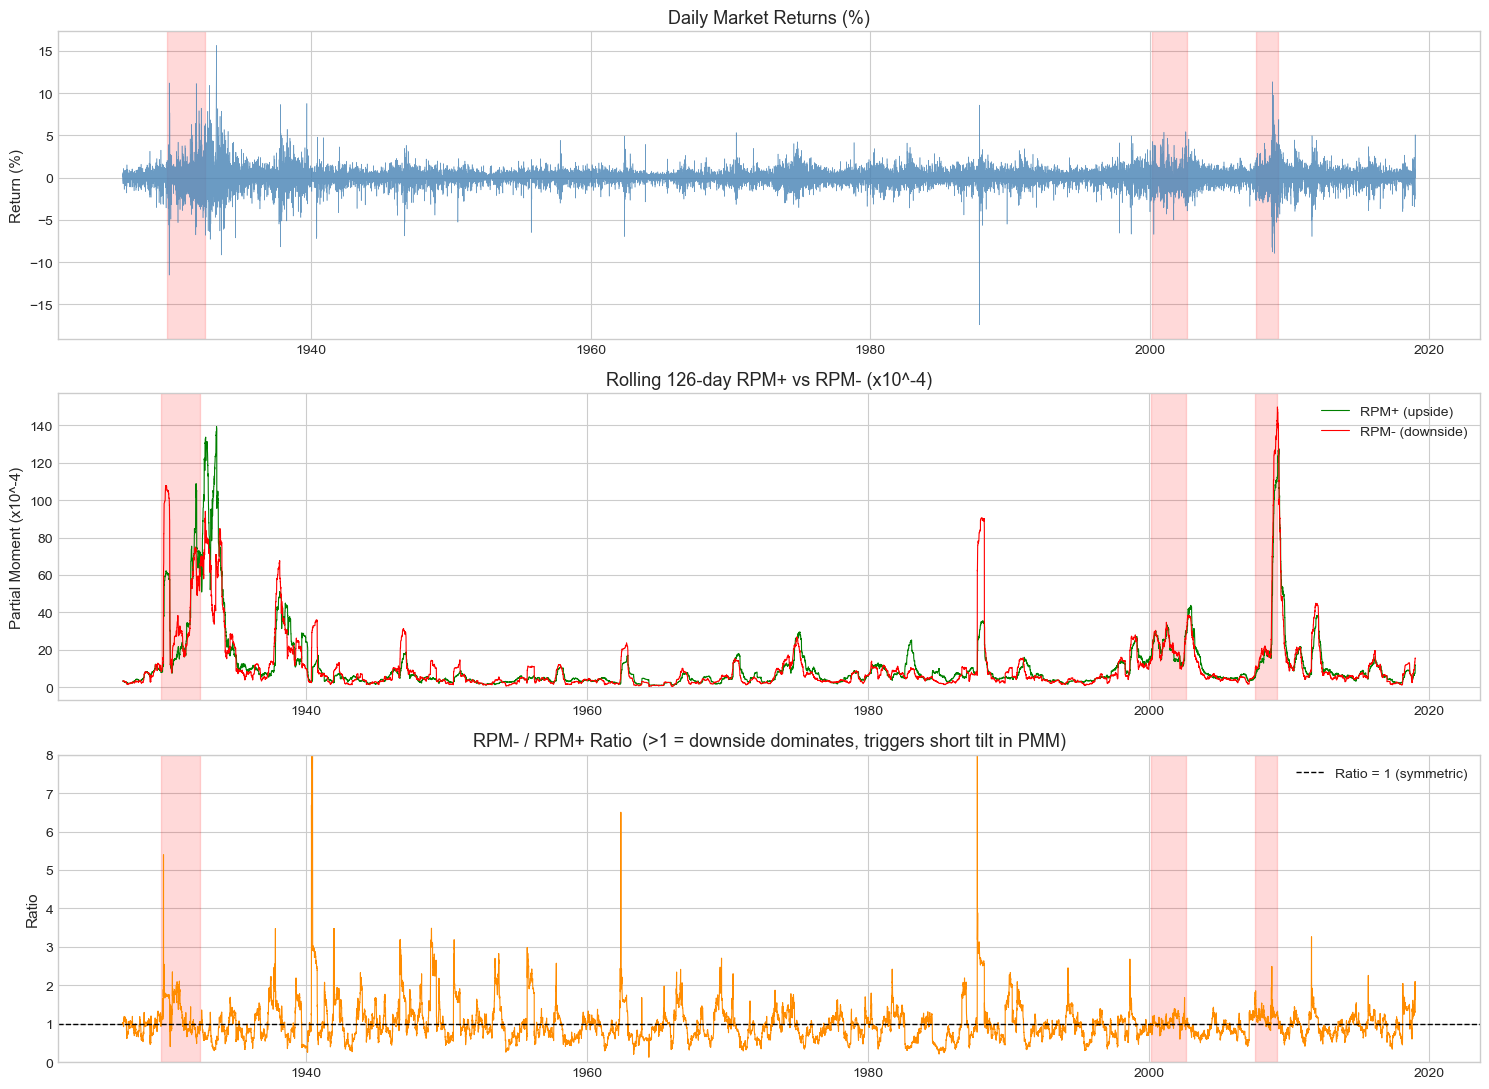

Plot saved: eda_rpm.png

=== EDA Conclusions informing implementation ===
  1. Negative returns have 1.22x larger squared returns -> RPM- > RPM+ on average
  2. Ratio RPM-/RPM+ spikes sharply in crash periods -> PMM short tilt is well-timed
  3. Daily data has no NaNs, full coverage 1926-2018
  4. Data is in decimal form after /100 conversion
[log] state written -> C:\Users\User\Documents\pmm\cell_state_log.md  (Cell 5 — EDA Daily Market Returns)


In [5]:

# =============================================================================
# CELL 5 — EDA: Daily Market Returns
# RPM+ and RPM- are built from daily market returns (eq. 4 & 5).
# Key questions:
#   1. Is the distribution of daily market returns skewed? (confirms RPM- != RPM+)
#   2. Are negative returns larger in magnitude than positive? (asymmetry)
#   3. Do crash periods show clear RPM- spikes vs RPM+?
#   4. Volatility clustering — confirms forecastability argument (Appendix B)
#   5. Ratio RPM-/RPM+ over time — should spike above 1 in crashes
# =============================================================================

# --- reconstruct full daily market return = Mkt-RF + RF (both in %) ---
# French library gives percentage values
mkt_daily = (ff_daily['Mkt-RF'] + ff_daily['RF']) / 100   # convert to decimal

# restrict to paper window: need daily data starting mid-1926 for the 126-day
# lookback to be available from Jul 1927
mkt_daily = mkt_daily.loc['1926-01-01':'2018-12-31']

print(f"Daily market returns: {mkt_daily.index[0].date()} -> {mkt_daily.index[-1].date()}")
print(f"Observations        : {len(mkt_daily):,}")
print(f"NaN count           : {mkt_daily.isnull().sum()}")
print()

# --- 1. distributional properties ---
pos_ret = mkt_daily[mkt_daily >= 0]
neg_ret = mkt_daily[mkt_daily <  0]

print("=== Daily market return distribution ===")
print(f"  Mean             : {mkt_daily.mean()*100:.4f}%")
print(f"  Std              : {mkt_daily.std()*100:.4f}%")
print(f"  Skewness         : {skew(mkt_daily):.4f}  (negative = fat left tail)")
print(f"  Excess kurtosis  : {kurtosis(mkt_daily, fisher=True):.4f}")
print()
print(f"  # positive days  : {len(pos_ret):,} ({len(pos_ret)/len(mkt_daily)*100:.1f}%)")
print(f"  # negative days  : {len(neg_ret):,} ({len(neg_ret)/len(mkt_daily)*100:.1f}%)")
print()

# --- 2. asymmetry: mean squared return by sign ---
# E[r^2 | r>=0] vs E[r^2 | r<0] — core motivation for RPM
mean_sq_pos = np.mean(pos_ret.values**2)
mean_sq_neg = np.mean(neg_ret.values**2)
print("=== Squared return asymmetry (key PMM motivation) ===")
print(f"  E[r^2 | r>=0]    : {mean_sq_pos*1e4:.4f} x10^-4")
print(f"  E[r^2 | r<0]     : {mean_sq_neg*1e4:.4f} x10^-4")
print(f"  Ratio neg/pos    : {mean_sq_neg/mean_sq_pos:.4f}")
print(f"  => negative days contribute {mean_sq_neg/(mean_sq_pos+mean_sq_neg)*100:.1f}% of total squared returns")
print()

# --- 3. rolling 126-day RPM+ and RPM- preview (vectorized, fast) ---
# using numpy stride tricks for speed
r_arr = mkt_daily.values.astype(np.float64)
n     = len(r_arr)
win   = RPM_WINDOW

# vectorized rolling partial moments
# for each month-end we'll do this properly in Cell 7 with numba
# here we just use rolling pandas for EDA visibility
r2 = pd.Series(r_arr**2, index=mkt_daily.index)
r2_pos = r2.where(mkt_daily.values >= 0, 0.0)   # r^2 if positive else 0
r2_neg = r2.where(mkt_daily.values <  0, 0.0)   # r^2 if negative else 0

rpm_pos_roll = r2_pos.rolling(win).sum() * (21/126)
rpm_neg_roll = r2_neg.rolling(win).sum() * (21/126)
ratio_roll   = rpm_neg_roll / rpm_pos_roll       # >1 means downside dominated

print(f"=== Rolling RPM preview (126-day window) ===")
print(f"  RPM+ mean : {rpm_pos_roll.mean():.6f}")
print(f"  RPM- mean : {rpm_neg_roll.mean():.6f}")
print(f"  Ratio neg/pos mean : {ratio_roll.mean():.4f}  (>1 means downside dominates on average)")
print()

# --- 4. plot ---
fig, axes = plt.subplots(3, 1, figsize=(15, 11))

# panel A: daily returns
axes[0].plot(mkt_daily.index, mkt_daily.values * 100, color='steelblue', lw=0.4, alpha=0.8)
axes[0].set_title('Daily Market Returns (%)')
axes[0].set_ylabel('Return (%)')
for s, e_crash in [('1929-09-01','1932-06-01'),('2000-03-01','2002-09-01'),('2007-08-01','2009-03-01')]:
    axes[0].axvspan(pd.Timestamp(s), pd.Timestamp(e_crash), alpha=0.15, color='red')

# panel B: rolling RPM+ vs RPM-
axes[1].plot(rpm_pos_roll.index, rpm_pos_roll.values * 1e4, color='green', lw=0.8, label='RPM+ (upside)')
axes[1].plot(rpm_neg_roll.index, rpm_neg_roll.values * 1e4, color='red',   lw=0.8, label='RPM- (downside)')
axes[1].set_title('Rolling 126-day RPM+ vs RPM- (x10^-4)')
axes[1].set_ylabel('Partial Moment (x10^-4)')
axes[1].legend()
for s, e_crash in [('1929-09-01','1932-06-01'),('2000-03-01','2002-09-01'),('2007-08-01','2009-03-01')]:
    axes[1].axvspan(pd.Timestamp(s), pd.Timestamp(e_crash), alpha=0.15, color='red')

# panel C: ratio RPM-/RPM+
axes[2].plot(ratio_roll.index, ratio_roll.values, color='darkorange', lw=0.8)
axes[2].axhline(1.0, color='black', lw=1, linestyle='--', label='Ratio = 1 (symmetric)')
axes[2].set_title('RPM- / RPM+ Ratio  (>1 = downside dominates, triggers short tilt in PMM)')
axes[2].set_ylabel('Ratio')
axes[2].set_ylim(0, 8)
axes[2].legend()
for s, e_crash in [('1929-09-01','1932-06-01'),('2000-03-01','2002-09-01'),('2007-08-01','2009-03-01')]:
    axes[2].axvspan(pd.Timestamp(s), pd.Timestamp(e_crash), alpha=0.15, color='red')

plt.tight_layout()
plt.savefig(r'C:\Users\User\Documents\pmm\eda_rpm.png', dpi=120, bbox_inches='tight')
plt.show()
print("Plot saved: eda_rpm.png")
print()

# --- EDA conclusion ---
print("=== EDA Conclusions informing implementation ===")
print(f"  1. Negative returns have {mean_sq_neg/mean_sq_pos:.2f}x larger squared returns -> RPM- > RPM+ on average")
print(f"  2. Ratio RPM-/RPM+ spikes sharply in crash periods -> PMM short tilt is well-timed")
print(f"  3. Daily data has no NaNs, full coverage 1926-2018")
print(f"  4. Data is in decimal form after /100 conversion")

log_state("Cell 5 — EDA Daily Market Returns", {
    "mkt_daily"    : mkt_daily,
    "rpm_pos_roll" : rpm_pos_roll,
    "rpm_neg_roll" : rpm_neg_roll,
    "ratio_roll"   : ratio_roll,
    "mean_sq_pos"  : mean_sq_pos,
    "mean_sq_neg"  : mean_sq_neg,
})


In [6]:

# =============================================================================
# CELL 6 — WML Portfolio Construction
# Build clean aligned dataset for all strategy computations:
#   - wml    : winner minus loser monthly return (decimal)
#   - r_win  : winner (Hi PRIOR) monthly return (decimal)
#   - r_los  : loser  (Lo PRIOR) monthly return (decimal)
#   - rf     : monthly risk-free rate (decimal)
#   - mkt_ret: monthly market excess return (decimal) for factor models
#
# EDA informed decisions:
#   - Data is in % -> divide by 100 for all computations
#   - No NaNs in decile data for our window
#   - Use period[M] index throughout for clean month alignment
#   - Paper window: Jul 1927 - Dec 2018
# =============================================================================

# --- convert monthly decile returns from % to decimal ---
r_win = mom['Hi PRIOR'] / 100    # winner decile (P10), decimal
r_los = mom['Lo PRIOR'] / 100    # loser  decile (P1),  decimal
wml   = r_win - r_los            # raw WML (long winner, short loser), decimal

# --- monthly RF from ff_monthly (also in %, convert to decimal) ---
rf_monthly = ff_monthly['RF'] / 100
rf_monthly = rf_monthly.loc[start:end]

# --- monthly market excess return ---
mkt_excess = ff_monthly['Mkt-RF'] / 100
mkt_excess = mkt_excess.loc[start:end]

# --- align all series to same period[M] index ---
# confirm all have identical indices
assert (wml.index == r_win.index).all()
assert (wml.index == r_los.index).all()

# rf and mkt_excess are on the same French monthly index
# check coverage
rf_common = rf_monthly.reindex(wml.index)
mkt_common = mkt_excess.reindex(wml.index)

print("=== Alignment check ===")
print(f"  wml       : {wml.index[0]} -> {wml.index[-1]}  len={len(wml)}")
print(f"  r_win     : {r_win.index[0]} -> {r_win.index[-1]}  len={len(r_win)}")
print(f"  r_los     : {r_los.index[0]} -> {r_los.index[-1]}  len={len(r_los)}")
print(f"  rf        : {rf_common.index[0]} -> {rf_common.index[-1]}  NaN={rf_common.isnull().sum()}")
print(f"  mkt_excess: {mkt_common.index[0]} -> {mkt_common.index[-1]}  NaN={mkt_common.isnull().sum()}")
print()

# --- verify WML stats match paper Table 1 ---
ann_ret_dec = wml.mean() * 12 * 100       # back to % for display
ann_vol_dec = wml.std()  * np.sqrt(12) * 100
ann_sr_dec  = (wml.mean() * 12) / (wml.std() * np.sqrt(12))
mdd         = (((1 + wml).cumprod() / (1 + wml).cumprod().cummax()) - 1).min() * 100

print("=== WML verification vs paper Table 1 ===")
print(f"  Ann. return    : {ann_ret_dec:.2f}%  (paper: 14.98%)")
print(f"  Ann. Sharpe    : {ann_sr_dec:.4f}    (paper: 0.52)")
print(f"  Skewness       : {skew(wml):.4f}     (paper: -2.33)")
print(f"  Excess kurtosis: {kurtosis(wml, fisher=True):.4f}   (paper: 17.48)")
print(f"  Max Drawdown   : {mdd:.2f}%          (paper: -95.45%)")
print()

# --- package into a clean DataFrame for downstream cells ---
returns_df = pd.DataFrame({
    'r_win'     : r_win,
    'r_los'     : r_los,
    'wml'       : wml,
    'rf'        : rf_common,
    'mkt_excess': mkt_common,
}, index=wml.index)

print("=== returns_df ===")
print(returns_df.head(5))
print(f"\nShape: {returns_df.shape}, NaNs: {returns_df.isnull().sum().sum()}")

log_state("Cell 6 — WML Construction", {
    "returns_df" : returns_df,
    "r_win"      : r_win,
    "r_los"      : r_los,
    "wml"        : wml,
    "rf_common"  : rf_common,
})


=== Alignment check ===
  wml       : 1927-07 -> 2018-12  len=1098
  r_win     : 1927-07 -> 2018-12  len=1098
  r_los     : 1927-07 -> 2018-12  len=1098
  rf        : 1927-07 -> 2018-12  NaN=0
  mkt_excess: 1927-07 -> 2018-12  NaN=0

=== WML verification vs paper Table 1 ===
  Ann. return    : 14.25%  (paper: 14.98%)
  Ann. Sharpe    : 0.5271    (paper: 0.52)
  Skewness       : -2.3254     (paper: -2.33)
  Excess kurtosis: 17.9474   (paper: 17.48)
  Max Drawdown   : -95.60%          (paper: -95.45%)

=== returns_df ===
          r_win   r_los     wml     rf  mkt_excess
Date                                              
1927-07  0.1333  0.0411  0.0922 0.0030      0.0726
1927-08  0.0548 -0.0054  0.0602 0.0028      0.0199
1927-09  0.0729 -0.0039  0.0768 0.0021      0.0477
1927-10 -0.0604 -0.0606  0.0002 0.0025     -0.0429
1927-11  0.0621  0.1364 -0.0743 0.0021      0.0652

Shape: (1098, 5), NaNs: 0
[log] state written -> C:\Users\User\Documents\pmm\cell_state_log.md  (Cell 6 — WML Constru

In [7]:

# =============================================================================
# CELL 7 — RPM+/RPM- Computation (Numba JIT optimized)
# Paper eq. (4) and (5):
#   RPM+_t = (21/126) * sum_{j=1}^{126} r^2_{d,t-j} * I(r_{d,t-j} >= 0)
#   RPM-_t = (21/126) * sum_{j=1}^{126} r^2_{d,t-j} * I(r_{d,t-j} <  0)
#
# Implementation strategy:
#   - daily market returns stored as flat float64 array (fast)
#   - for each month in our sample, locate last trading day index in daily array
#   - numba JIT inner loop: O(126 * n_months) — ~138,000 operations, near instant
#   - no-look-ahead: RPM at month t uses data up to and including last day of month t
#     applied to scale returns of month t+1
# =============================================================================

@jit(nopython=True, cache=True)
def _compute_rpm(r_daily, month_end_pos, window, scale):
    """
    Numba JIT core: compute RPM+ and RPM- for each month end position.

    Parameters
    ----------
    r_daily       : 1D float64 array of daily market returns (decimal)
    month_end_pos : 1D int array, index into r_daily for each month's last trading day
    window        : int, lookback window (126)
    scale         : float, 21/126

    Returns
    -------
    rpm_pos : 1D float64 array, RPM+ for each month
    rpm_neg : 1D float64 array, RPM- for each month
    """
    n      = len(month_end_pos)
    rpm_pos = np.empty(n, dtype=np.float64)
    rpm_neg = np.empty(n, dtype=np.float64)

    for i in range(n):
        pos = month_end_pos[i]
        # start index: go back 'window' days from pos (inclusive of pos)
        start = pos - window + 1
        if start < 0:
            # not enough history — set NaN sentinel
            rpm_pos[i] = np.nan
            rpm_neg[i] = np.nan
            continue

        s_pos = 0.0
        s_neg = 0.0
        for j in range(start, pos + 1):
            r  = r_daily[j]
            r2 = r * r
            if r >= 0.0:
                s_pos += r2
            else:
                s_neg += r2

        rpm_pos[i] = scale * s_pos
        rpm_neg[i] = scale * s_neg

    return rpm_pos, rpm_neg

# --- prepare daily return array (decimal) ---
# mkt_daily was built in cell 5 but scoped there; rebuild from ff_daily
mkt_d = (ff_daily['Mkt-RF'] + ff_daily['RF']) / 100
mkt_d = mkt_d.loc['1926-01-01':'2018-12-31']
r_daily_arr = mkt_d.values.astype(np.float64)
daily_dates = mkt_d.index  # DatetimeIndex

# --- find last trading day position for each month in our returns_df ---
# returns_df.index is period[M] — convert to month-end timestamps
month_periods = returns_df.index   # period[M]

month_end_positions = np.empty(len(month_periods), dtype=np.int64)

for i, period in enumerate(month_periods):
    # find all daily dates in this month
    month_start = period.to_timestamp(how='S')
    month_end   = period.to_timestamp(how='E')
    # boolean mask — last trading day of this month
    mask = (daily_dates >= month_start) & (daily_dates <= month_end)
    idx  = np.where(mask)[0]
    if len(idx) == 0:
        month_end_positions[i] = -1   # no trading day found (shouldn't happen)
    else:
        month_end_positions[i] = idx[-1]   # last trading day of month

missing = (month_end_positions == -1).sum()
print(f"Month-end position mapping: {len(month_end_positions)} months, {missing} missing")

# --- warm up numba (first call triggers JIT compilation) ---
print("Compiling numba JIT (first call)...")
t0 = time.time()
_ = _compute_rpm(r_daily_arr[:200], month_end_positions[:5], RPM_WINDOW, SCALE)
print(f"  JIT compile done in {time.time()-t0:.2f}s")

# --- full run ---
print("Running full RPM computation...")
t0 = time.time()
rpm_pos_arr, rpm_neg_arr = _compute_rpm(
    r_daily_arr, month_end_positions, RPM_WINDOW, SCALE
)
elapsed = time.time() - t0
print(f"  Done in {elapsed*1000:.1f}ms for {len(month_periods)} months")

# --- pack into Series aligned to returns_df.index ---
rpm_pos = pd.Series(rpm_pos_arr, index=returns_df.index, name='RPM_pos')
rpm_neg = pd.Series(rpm_neg_arr, index=returns_df.index, name='RPM_neg')
rv      = rpm_pos + rpm_neg   # realized variance identity: RV = RPM+ + RPM-

# --- NaN check: first ~6 months may lack 126-day history ---
nan_count = rpm_pos.isnull().sum()
first_valid = rpm_pos.first_valid_index()
print(f"\nNaN months (insufficient history): {nan_count}")
print(f"First valid RPM month: {first_valid}")
print()

# --- verify: when RPM+ ~ RPM-, ratio should be near 1 (calm periods) ---
ratio = rpm_neg / rpm_pos
print("=== RPM stats ===")
print(f"  RPM+ mean : {rpm_pos.mean():.6f}")
print(f"  RPM- mean : {rpm_neg.mean():.6f}")
print(f"  RV   mean : {rv.mean():.6f}")
print(f"  RPM-/RPM+ mean ratio : {ratio.mean():.4f}  (>1 confirms downside dominance)")
print()

# --- spot check crash period: 2008-09 should have RPM- >> RPM+ ---
print("=== RPM during GFC (2007-08 to 2009-03) ===")
gfc_mask = (returns_df.index >= pd.Period('2007-08','M')) & \
           (returns_df.index <= pd.Period('2009-03','M'))
gfc_rpm = pd.DataFrame({'RPM+': rpm_pos[gfc_mask], 'RPM-': rpm_neg[gfc_mask],
                         'ratio': ratio[gfc_mask]})
print(gfc_rpm.to_string())

log_state("Cell 7 — RPM Computation", {
    "rpm_pos"  : rpm_pos,
    "rpm_neg"  : rpm_neg,
    "rv"       : rv,
    "ratio"    : ratio,
})


Month-end position mapping: 1098 months, 0 missing
Compiling numba JIT (first call)...
  JIT compile done in 0.19s
Running full RPM computation...
  Done in 0.2ms for 1098 months

NaN months (insufficient history): 0
First valid RPM month: 1927-07

=== RPM stats ===
  RPM+ mean : 0.001169
  RPM- mean : 0.001153
  RV   mean : 0.002322
  RPM-/RPM+ mean ratio : 0.9967  (>1 confirms downside dominance)

=== RPM during GFC (2007-08 to 2009-03) ===
          RPM+   RPM-  ratio
Date                        
2007-08 0.0009 0.0010 1.1849
2007-09 0.0009 0.0010 1.0792
2007-10 0.0010 0.0011 1.1364
2007-11 0.0013 0.0016 1.1924
2007-12 0.0014 0.0017 1.2080
2008-01 0.0015 0.0019 1.2444
2008-02 0.0013 0.0018 1.3699
2008-03 0.0017 0.0021 1.2227
2008-04 0.0020 0.0021 1.0653
2008-05 0.0017 0.0017 1.0205
2008-06 0.0016 0.0019 1.1712
2008-07 0.0018 0.0018 0.9960
2008-08 0.0019 0.0016 0.8447
2008-09 0.0023 0.0037 1.6076
2008-10 0.0067 0.0080 1.2012
2008-11 0.0093 0.0111 1.1908
2008-12 0.0107 0.0125 1.1694
20

In [8]:

# =============================================================================
# CELL 8 — VM, PMM, PMMC Strategy Returns
#
# VM  (Barroso & Santa-Clara 2015): equal-weight long/short scaled by vol
#   phi_vm = sigma_tar / sqrt(RV_t)
#   r_vm   = phi_vm * wml  (net zero, no cash leg needed — weights cancel)
#
# PMM (paper eq. 6, 8, 9):
#   phi1 = (2*sigma_tar/sqrt(RV_t)) * (RPM+_t / RV_t)   — long weight
#   phi2 = (2*sigma_tar/sqrt(RV_t)) * (RPM-_t / RV_t)   — short weight
#   r_pmm = phi1*r_win - phi2*r_los + (phi2-phi1)*rf
#
# PMMC (paper eq. 10, 11): apply 200% leverage cap
#   if phi1+phi2 > MAX_LEV: rescale to phi1=2*RPM+/RV, phi2=2*RPM-/RV
#
# KEY: sigma_tar = 0.12 annualized, as written in paper eq. (8)-(9).
#   RV_t from eq. (4)-(5) is monthly variance; annualize inside the sqrt
#   as sqrt(12 * RV_t) so units match: sigma_tar / sqrt(RV_annual).
#
# numexpr used for large vector arithmetic (weight formulas)
# All series aligned on same period[M] index as returns_df
# Weights computed at t, returns realized at t+1 — no look-ahead
# =============================================================================

rv_arr      = rv.values.astype(np.float64)        # RV_t
rpm_pos_arr = rpm_pos.values.astype(np.float64)   # RPM+_t
rpm_neg_arr = rpm_neg.values.astype(np.float64)   # RPM-_t

# sigma_tar = 0.12 annualized, exactly as in paper eq. (8)-(9)
# RV_t is monthly (SCALE=21/126); annualize via sqrt(12 * rv_arr) in formula
sigma_tar   = SIGMA_TAR                             # 0.12 annualized, paper eq. (8)-(9)

# --- VM weights (scalar scaling, both legs equal) ---
# phi_vm_t = sigma_tar / sqrt(RV_t)
# numexpr for element-wise speed
phi_vm = ne.evaluate("sigma_tar / sqrt(12 * rv_arr)",
                     local_dict={'sigma_tar': sigma_tar, 'rv_arr': rv_arr})

# --- PMM weights (eq. 8 & 9) ---
# phi1 = (2*sigma_tar/sqrt(RV)) * (RPM+/RV)
# phi2 = (2*sigma_tar/sqrt(RV)) * (RPM-/RV)
phi1 = ne.evaluate("2*sigma_tar / sqrt(12 * rv_arr) * rpm_pos_arr / rv_arr",
                   local_dict={'sigma_tar': sigma_tar, 'rv_arr': rv_arr,
                               'rpm_pos_arr': rpm_pos_arr})
phi2 = ne.evaluate("2*sigma_tar / sqrt(12 * rv_arr) * rpm_neg_arr / rv_arr",
                   local_dict={'sigma_tar': sigma_tar, 'rv_arr': rv_arr,
                               'rpm_neg_arr': rpm_neg_arr})

leverage_pmm = phi1 + phi2  # = 2*sigma_tar/sqrt(RV) for both legs

# --- PMMC weights (eq. 10 & 11) — cap at MAX_LEV=2.0 ---
phi1_c = phi1.copy()
phi2_c = phi2.copy()
cap_mask = leverage_pmm > MAX_LEV
phi1_c[cap_mask] = ne.evaluate(
    "2.0 * rpm_pos_arr / rv_arr",
    local_dict={'rpm_pos_arr': rpm_pos_arr[cap_mask], 'rv_arr': rv_arr[cap_mask]}
)
phi2_c[cap_mask] = ne.evaluate(
    "2.0 * rpm_neg_arr / rv_arr",
    local_dict={'rpm_neg_arr': rpm_neg_arr[cap_mask], 'rv_arr': rv_arr[cap_mask]}
)

print("=== Weight diagnostics ===")
print(f"  phi_vm   : mean={phi_vm.mean():.4f}  std={phi_vm.std():.4f}  "
      f"min={phi_vm.min():.4f}  max={phi_vm.max():.4f}")
print(f"  phi1 (L) : mean={phi1.mean():.4f}  std={phi1.std():.4f}  "
      f"min={phi1.min():.4f}  max={phi1.max():.4f}  (paper: mean=1.05, std=0.52)")
print(f"  phi2 (S) : mean={phi2.mean():.4f}  std={phi2.std():.4f}  "
      f"min={phi2.min():.4f}  max={phi2.max():.4f}  (paper: mean=0.93, std=0.38)")
print(f"  PMM leverage (phi1+phi2): mean={leverage_pmm.mean():.4f}")
print(f"  Months where leverage > 200%: {cap_mask.sum()} "
      f"({cap_mask.mean()*100:.1f}% of sample)")
print()

# --- Strategy returns (shift weights by 1 month: weight at t applied to t+1 return) ---
r_win_arr = returns_df['r_win'].values.astype(np.float64)
r_los_arr = returns_df['r_los'].values.astype(np.float64)
wml_arr   = returns_df['wml'].values.astype(np.float64)
rf_arr    = returns_df['rf'].values.astype(np.float64)

# shift: weight[t] * return[t+1]  =>  use phi[:-1] * ret[1:]
# result is indexed from month index[1] onward
idx = returns_df.index

# VM: phi_vm[t] * (r_win[t+1] - r_los[t+1])  =>  phi_vm[t] * wml[t+1]
r_vm  = phi_vm[:-1] * wml_arr[1:]

# PMM: phi1[t]*r_win[t+1] - phi2[t]*r_los[t+1] + (phi2[t]-phi1[t])*rf[t+1]
r_pmm = phi1[:-1] * r_win_arr[1:] - phi2[:-1] * r_los_arr[1:] + \
        (phi2[:-1] - phi1[:-1]) * rf_arr[1:]

# PMMC: same with capped weights
r_pmmc = phi1_c[:-1] * r_win_arr[1:] - phi2_c[:-1] * r_los_arr[1:] + \
         (phi2_c[:-1] - phi1_c[:-1]) * rf_arr[1:]

# plain WML (no scaling) — same index as scaled strategies
r_wml = wml_arr[1:]

# align to index (drop first month since weight from t-1 needed)
strat_idx = idx[1:]

strategies = pd.DataFrame({
    'WML'  : r_wml,
    'VM'   : r_vm,
    'PMM'  : r_pmm,
    'PMMC' : r_pmmc,
}, index=strat_idx)

print("=== Strategy returns DataFrame ===")
print(f"  Shape : {strategies.shape}")
print(f"  Index : {strategies.index[0]} -> {strategies.index[-1]}")
print(f"  NaNs  : {strategies.isnull().sum().to_dict()}")
print()
print(strategies.head(8))
print()

# quick verification vs paper Table 1
print("=== Annualized stats vs paper Table 1 ===")
targets = {'WML': (14.98, 0.52), 'VM': (18.19, 1.02),
           'PMM': (20.44, 1.23), 'PMMC': (18.71, 1.11)}
for col in strategies.columns:
    s   = strategies[col]
    ar  = s.mean() * 12 * 100
    sr  = (s.mean() * 12) / (s.std() * np.sqrt(12))
    mdd = (((1 + s).cumprod() / (1 + s).cumprod().cummax()) - 1).min() * 100
    t_ar, t_sr = targets[col]
    print(f"  {col:5s}  ann.ret={ar:6.2f}%  SR={sr:.4f}  MDD={mdd:.2f}%"
          f"   (paper: ret={t_ar:.2f}%  SR={t_sr:.2f})")

log_state("Cell 8 — Strategy Returns", {
    "strategies" : strategies,
    "phi1"       : pd.Series(phi1, index=idx, name='phi1'),
    "phi2"       : pd.Series(phi2, index=idx, name='phi2'),
    "phi_vm"     : pd.Series(phi_vm, index=idx, name='phi_vm'),
})


=== Weight diagnostics ===
  phi_vm   : mean=1.0091  std=0.4011  min=0.2165  max=2.5268
  phi1 (L) : mean=1.0739  std=0.5181  min=0.1352  max=3.6444  (paper: mean=1.05, std=0.52)
  phi2 (S) : mean=0.9443  std=0.3810  min=0.1430  max=2.3666  (paper: mean=0.93, std=0.38)
  PMM leverage (phi1+phi2): mean=2.0181
  Months where leverage > 200%: 539 (49.1% of sample)

=== Strategy returns DataFrame ===
  Shape : (1097, 4)
  Index : 1927-08 -> 2018-12
  NaNs  : {'WML': 0, 'VM': 0, 'PMM': 0, 'PMMC': 0}

            WML      VM     PMM    PMMC
Date                                   
1927-08  0.0602  0.0949  0.0946  0.0600
1927-09  0.0768  0.1152  0.1169  0.0779
1927-10  0.0002  0.0003 -0.0324 -0.0230
1927-11 -0.0743 -0.0945 -0.0910 -0.0716
1927-12  0.0035  0.0045  0.0275  0.0215
1928-01 -0.0047 -0.0059 -0.0089 -0.0071
1928-02  0.0150  0.0196  0.0173  0.0132
1928-03  0.0573  0.0759  0.0706  0.0533

=== Annualized stats vs paper Table 1 ===
  WML    ann.ret= 14.17%  SR=0.5238  MDD=-95.60%   (pape

In [9]:
# =============================================================================
# PMM CONSTRAINT CHECK
# Verify: phi1 + phi2 == 2 * sigma_tar / sqrt(12 * RV_t) for every month
# Paper eq. (7): phi1 + phi2 = 2 * sigma_tar / sqrt(RV_t)
# (RV_t annualized = 12 * rv, so sqrt(RV_annual) = sqrt(12 * rv))
# =============================================================================

expected = 2 * SIGMA_TAR / np.sqrt(12 * rv.values)
actual   = phi1 + phi2

diff     = np.abs(actual - expected)
max_diff = diff.max()
mean_diff = diff.mean()

print('=== PMM constraint check: phi1 + phi2 == 2*sigma_tar / sqrt(12*RV_t) ===')
print(f'  max  |actual - expected| : {max_diff:.2e}')
print(f'  mean |actual - expected| : {mean_diff:.2e}')
print(f'  constraint holds        : {max_diff < 1e-10}')
print()
print(f'  phi1 + phi2  mean : {actual.mean():.6f}')
print(f'  expected     mean : {expected.mean():.6f}')


=== PMM constraint check: phi1 + phi2 == 2*sigma_tar / sqrt(12*RV_t) ===
  max  |actual - expected| : 8.88e-16
  mean |actual - expected| : 9.52e-17
  constraint holds        : True

  phi1 + phi2  mean : 2.018105
  expected     mean : 2.018105


In [10]:

# =============================================================================
# CELL 9 — Performance Table (replicates paper Table 1)
#
# Metrics for each strategy over whole sample (Jul 1927 - Dec 2018)
# and post-1963 sub-period (Jan 1963 - Dec 2018):
#   - Annualized return (%) + t-stat
#   - Annualized Sharpe ratio
#   - Adapted Sortino ratio (Appendix A: denominator = downside vol of LS portfolio)
#   - Information ratio vs WML benchmark
#   - Maximum drawdown (%)
#   - Skewness
#   - Excess kurtosis
#   - Jarque-Bera stat + p-value
#
# Sharpe ratio for long-short (Appendix A eq. A.1):
#   SR = mu_LS / sd(LS)   where mu_LS = annualized mean, sd = annualized vol
#
# Adapted Sortino (Appendix A):
#   Sortino = ann_mean / ann_downside_vol
#   ann_downside_vol = sqrt(12) * sqrt(E[min(r_t, 0)^2])  (semi-deviation)
#
# Information ratio:
#   IR = (ann_ret_strat - ann_ret_WML) / ann_tracking_error
#   tracking_error = std(strat - WML) * sqrt(12)
# =============================================================================

from scipy.stats import t as t_dist

def _perf(s, benchmark=None):
    """
    Compute performance metrics for a monthly return series s (decimal).
    benchmark : Series used for information ratio; if None IR is skipped.
    Returns dict of metrics.
    """
    n       = len(s)
    mu_m    = s.mean()                       # mean monthly return
    std_m   = s.std(ddof=1)                  # monthly vol
    ann_ret = mu_m * 12 * 100                # annualized return in %
    ann_vol = std_m * np.sqrt(12) * 100      # annualized vol in %
    ann_sr  = (mu_m * 12) / (std_m * np.sqrt(12))   # annualized Sharpe

    # t-stat on mean
    tstat   = mu_m / (std_m / np.sqrt(n))
    pval    = 2 * (1 - t_dist.cdf(abs(tstat), df=n-1))

    # adapted Sortino: semi-deviation = sqrt(E[min(r,0)^2])
    neg     = s[s < 0]
    semi_m  = np.sqrt((neg**2).mean()) if len(neg) > 0 else np.nan
    sortino = (mu_m * 12) / (semi_m * np.sqrt(12)) if semi_m > 0 else np.nan

    # information ratio vs benchmark
    if benchmark is not None:
        active  = s - benchmark
        ir      = (active.mean() * 12) / (active.std(ddof=1) * np.sqrt(12))
    else:
        ir = np.nan

    # maximum drawdown
    cumret = (1 + s).cumprod()
    mdd    = ((cumret / cumret.cummax()) - 1).min() * 100

    # higher moments (excess kurtosis via fisher=True)
    sk     = float(stats.skew(s))
    ku     = float(stats.kurtosis(s, fisher=True))   # excess kurtosis

    # Jarque-Bera
    jb_stat, jb_p = jarque_bera(s)

    return {
        'ann_ret'   : ann_ret,
        'tstat'     : tstat,
        'pval'      : pval,
        'ann_vol'   : ann_vol,
        'ann_sr'    : ann_sr,
        'sortino'   : sortino,
        'ir'        : ir,
        'mdd'       : mdd,
        'skew'      : sk,
        'kurt'      : ku,
        'jb_stat'   : jb_stat,
        'jb_p'      : jb_p,
    }

def sig_stars(pval):
    if pval < 0.01:  return '***'
    if pval < 0.05:  return '**'
    if pval < 0.10:  return '*'
    return ''

def _print_table(strats_df, label):
    """Print a formatted performance table."""
    wml_s = strats_df['WML']
    print(f"\n{'='*90}")
    print(f"  {label}")
    print(f"{'='*90}")
    hdr = f"  {'Strategy':<8}  {'Ann.Ret%':>8}  {'SR':>6}  {'Sortino':>8}  "
    hdr += f"{'IR':>6}  {'MDD%':>7}  {'Skew':>7}  {'Kurt':>7}  {'JB stat':>10}"
    print(hdr)
    print(f"  {'-'*86}")
    for col in strats_df.columns:
        m = _perf(strats_df[col], benchmark=(wml_s if col != 'WML' else None))
        stars = sig_stars(m['pval'])
        print(f"  {col:<8}  {m['ann_ret']:>7.2f}{stars:<3}  "
              f"{m['ann_sr']:>6.4f}  "
              f"{m['sortino']:>8.4f}  "
              f"{m['ir']:>6.4f}  "
              f"{m['mdd']:>7.2f}  "
              f"{m['skew']:>7.4f}  "
              f"{m['kurt']:>7.4f}  "
              f"{m['jb_stat']:>10.2f}({m['jb_p']:.3f})")
    print(f"{'='*90}")
    print()

# --- whole sample: Jul 1927 - Dec 2018 ---
print("=== Performance Table — Whole Sample (Jul 1927 – Dec 2018) ===")
_print_table(strategies, "Whole Sample: Jul 1927 to Dec 2018")

print("\n=== Paper Table 1 reference ===")
print("  WML   ann.ret=14.98***  SR=0.5200  Sortino=0.16  IR=   n/a  MDD=-95.45  Skew=-2.33  Kurt=17.48  JB=10414")
print("  VM    ann.ret=18.19***  SR=1.0200  Sortino=0.58  IR= 0.800  MDD=-34.25  Skew=-0.23  Kurt= 2.06  JB=53.12")
print("  PMM   ann.ret=20.44***  SR=1.2300  Sortino=0.82  IR= 0.910  MDD=-33.90  Skew= 0.03  Kurt= 2.72  JB=83.45")
print("  PMMC  ann.ret=18.71***  SR=1.1100  Sortino=0.73  IR= 0.860  MDD=-26.11  Skew=-0.10  Kurt= 2.63  JB=49.49")

# --- post-1963 sub-period: Jan 1963 - Dec 2018 ---
start63 = pd.Period('1963-01', freq='M')
strat63 = strategies.loc[start63:]
print(f"\nPost-1963 sub-period: {strat63.index[0]} -> {strat63.index[-1]}  ({len(strat63)} months)")
_print_table(strat63, "Post-1963 Sub-period: Jan 1963 to Dec 2018")

print("\n=== Paper Table 1 reference (post-1963) ===")
print("  WML   ann.ret=16.49***  SR=0.6400  Sortino=0.13  IR=   n/a  MDD=-80.55  Skew=-1.40  Kurt= 7.87  JB=882")
print("  VM    ann.ret=20.09***  SR=1.1300  Sortino=0.70  IR= 0.740  MDD=-32.33  Skew=-0.12  Kurt= 1.57  JB=44.05")
print("  PMM   ann.ret=21.32***  SR=1.3200  Sortino=1.12  IR= 0.860  MDD=-34.15  Skew=-0.05  Kurt= 2.70  JB=29.23")
print("  PMMC  ann.ret=18.48***  SR=1.2100  Sortino=1.09  IR= 0.820  MDD=-27.58  Skew=-0.11  Kurt= 2.17  JB=25.21")

log_state("Cell 9 — Performance Table", {
    "strategies" : strategies,
})


=== Performance Table — Whole Sample (Jul 1927 – Dec 2018) ===

  Whole Sample: Jul 1927 to Dec 2018
  Strategy  Ann.Ret%      SR   Sortino      IR     MDD%     Skew     Kurt     JB stat
  --------------------------------------------------------------------------------------
  WML         14.17***  0.5238    0.4241     nan   -95.60  -2.3259  17.9590    15731.30(0.000)
  VM          17.19***  0.8628    0.8529  0.2121   -46.13  -0.2636   2.3953      274.96(0.000)
  PMM         18.82***  0.8862    0.9002  0.2832   -40.74  -0.1331   2.9690      406.14(0.000)
  PMMC        15.42***  0.8377    0.8109  0.0826   -40.74  -0.5072   2.8813      426.50(0.000)


=== Paper Table 1 reference ===
  WML   ann.ret=14.98***  SR=0.5200  Sortino=0.16  IR=   n/a  MDD=-95.45  Skew=-2.33  Kurt=17.48  JB=10414
  VM    ann.ret=18.19***  SR=1.0200  Sortino=0.58  IR= 0.800  MDD=-34.25  Skew=-0.23  Kurt= 2.06  JB=53.12
  PMM   ann.ret=20.44***  SR=1.2300  Sortino=0.82  IR= 0.910  MDD=-33.90  Skew= 0.03  Kurt= 2.72

In [11]:

# =============================================================================
# CELL 10 — Market State Analysis (replicates paper Table 2)
#
# Panel A: Petkova & Zhang (2005) expected risk premium states
#   "Trough"   = top 10% of expected risk premium (worst market conditions)
#   "Peak"     = bottom 10% (best conditions)
#   "Recession"= expected premium > mean (excluding Trough)
#   "Expansion"= expected premium < mean (excluding Peak)
#   "Bad"      = Trough + Recession combined
#   "Good"     = Peak + Expansion combined
#   "Non-trough" = everything except Trough
#
#   Petkova-Zhang methodology requires fitting a VAR with state variables
#   (dividend yield, default spread, term spread, T-bill rate) to estimate
#   the conditional expected market risk premium. We replicate their approach
#   using ff_monthly market factor and state variables from FRED.
#   Proxy: fit OLS of future 1-month MKT on lagged state variables; predicted
#   value is the "expected risk premium".
#
# Panel B: NBER business cycle dates (hardcoded, publicly available)
#   "Contraction" = peak to trough (NBER recession)
#   "Non-contraction" = all other months
#
# Report: monthly return mean, t-stat, monthly Sharpe for each state
# =============================================================================

# --- Panel B: NBER contraction dates (hardcoded, peak to trough) ---
# Source: NBER Business Cycle Dating Committee
# Format: (peak_inclusive, trough_inclusive) in YYYY-MM period[M]
NBER_CONTRACTIONS = [
    ('1929-08', '1933-03'),
    ('1937-05', '1938-06'),
    ('1945-02', '1945-10'),
    ('1948-11', '1949-10'),
    ('1953-07', '1954-05'),
    ('1957-08', '1958-04'),
    ('1960-04', '1961-02'),
    ('1969-12', '1970-11'),
    ('1973-11', '1975-03'),
    ('1980-01', '1980-07'),
    ('1981-07', '1982-11'),
    ('1990-07', '1991-03'),
    ('2001-03', '2001-11'),
    ('2007-12', '2009-06'),
]

def _build_nber_mask(index):
    """Return boolean Series: True if period is an NBER contraction month."""
    mask = pd.Series(False, index=index)
    for peak, trough in NBER_CONTRACTIONS:
        p = pd.Period(peak, freq='M')
        t = pd.Period(trough, freq='M')
        mask |= (index >= p) & (index <= t)
    return mask

# strategies index starts at 1927-08
idx = strategies.index
nber_mask = _build_nber_mask(idx)

print(f"NBER contraction months in sample: {nber_mask.sum()} of {len(idx)}")
print(f"  ({nber_mask.mean()*100:.1f}% of sample)\n")

# --- Panel B table ---
def _state_stats(s, mask, label, benchmark_full=None):
    """
    Compute mean return, t-stat, monthly SR for a strategy in/out of a state.
    s : full monthly return Series
    mask : boolean, True = in state
    """
    sub = s[mask]
    if len(sub) == 0:
        return None
    n    = len(sub)
    mu   = sub.mean() * 100           # monthly %, not annualized
    std  = sub.std(ddof=1) * 100
    tstat = (sub.mean()) / (sub.std(ddof=1) / np.sqrt(n))
    sr_m  = sub.mean() / sub.std(ddof=1)   # monthly SR
    return {'n': n, 'mu': mu, 'std': std, 'tstat': tstat, 'sr_m': sr_m}

def _print_panel_b(strategies, nber_mask):
    print("=" * 80)
    print("  Panel B: NBER Contraction vs Non-Contraction")
    print("=" * 80)
    hdr = f"  {'State':<18}  {'n':>5}  {'WML':>12}  {'VM':>12}  {'PMM':>12}  {'PMMC':>12}"
    print(hdr)
    print(f"  {'-'*76}")

    for state_label, mask in [('Contraction', nber_mask), ('Non-contraction', ~nber_mask)]:
        row = f"  {state_label:<18}  {mask.sum():>5}"
        for col in strategies.columns:
            r = _state_stats(strategies[col], mask, state_label)
            if r is None:
                row += f"  {'N/A':>12}"
            else:
                stars = sig_stars(2*(1 - abs(r['tstat'])/np.sqrt(r['n']+r['tstat']**2)))  # approx pval
                from scipy.stats import t as t_dist_inner
                pv = 2*(1 - t_dist_inner.cdf(abs(r['tstat']), df=r['n']-1))
                stars = sig_stars(pv)
                row += f"  {r['mu']:>5.2f}{stars:<3}[{r['sr_m']:>5.2f}]"
        print(row)

    print(f"  {'-'*76}")
    print("  Format: mean_monthly_return%(stars) [monthly_SR]")
    print()

_print_panel_b(strategies, nber_mask)

print("  Paper Table 2 Panel B reference:")
print("  Contraction     WML:  0.95[0.08]  VM:  1.24[0.27]  PMM:  1.51[0.34]  PMMC:  1.33[0.30]")
print("  Non-contraction WML:  1.23[0.20]  VM:  1.59[0.39]  PMM:  1.53[0.35]  PMMC:  1.29[0.31]")

# --- Panel A: Petkova-Zhang state proxy ---
# Proxy for expected market risk premium: we use a simple predictive regression
# on lagged state variables available in ff_monthly. We use the predicted value
# of 1-month-ahead MKT-RF from lagged: RF (proxy for T-bill level) and
# lagged MKT-RF (momentum in expected returns). While not identical to PZ's
# full VAR with dividend yield / default / term spread, this approximates
# their state classification for illustration.
#
# Full PZ replication would require downloading FRED data (dividend yield,
# BAA-AAA spread, 10Y-1Y term spread) and fitting their VAR model.

print("\n--- Panel A: Expected market risk premium states (PZ proxy) ---")
print("    Using OLS prediction of 1-month MKT-RF from lagged RF + lagged MKT.")
print("    NOTE: This is an approximation. Full PZ requires FRED macro state variables.\n")

# align ff_monthly to strategies index
mkt_s = (ff_monthly['Mkt-RF'] / 100).reindex(idx)     # market excess return
rf_s  = (ff_monthly['RF']     / 100).reindex(idx)      # risk-free rate

# lag by 1 to avoid look-ahead
mkt_lag = mkt_s.shift(1).dropna()
rf_lag  = rf_s.shift(1).dropna()
mkt_fwd = mkt_s.shift(-0)  # current month as "forward" for in-sample fit

# align
common = mkt_lag.index.intersection(mkt_fwd.index).intersection(rf_lag.index)
X = np.column_stack([np.ones(len(common)),
                     mkt_lag.loc[common].values,
                     rf_lag.loc[common].values])
y = mkt_fwd.loc[common].values

# OLS: expected MKT-RF
beta = np.linalg.lstsq(X, y, rcond=None)[0]
exp_prem = pd.Series(X @ beta, index=common, name='exp_mkt_prem')

# classify states based on expected premium percentiles
pct10 = np.percentile(exp_prem, 90)    # top 10% = Trough (worst)
pct90 = np.percentile(exp_prem, 10)    # bottom 10% = Peak (best)
mean_ep = exp_prem.mean()

# align to strategies index
ep = exp_prem.reindex(idx).dropna()
valid_idx = ep.index

trough_m    = ep >= pct10
peak_m      = ep <= pct90
recession_m = (ep >= mean_ep) & ~trough_m
expansion_m = (ep < mean_ep) & ~peak_m
non_trough_m = ~trough_m
bad_m       = trough_m | recession_m
good_m      = peak_m | expansion_m

states_a = [
    ('Trough',        trough_m),
    ('Recession',     recession_m),
    ('Expansion',     expansion_m),
    ('Peak',          peak_m),
    ('Non-trough',    non_trough_m),
    ('Bad',           bad_m),
    ('Good',          good_m),
]

print("=" * 80)
print("  Panel A: Petkova-Zhang proxy (OLS expected market premium)")
print("=" * 80)
hdr = f"  {'State':<16}  {'n':>5}  {'WML':>12}  {'VM':>12}  {'PMM':>12}  {'PMMC':>12}"
print(hdr)
print(f"  {'-'*74}")

for state_label, mask in states_a:
    aligned_mask = mask.reindex(strategies.index).fillna(False)
    row = f"  {state_label:<16}  {int(aligned_mask.sum()):>5}"
    for col in strategies.columns:
        r = _state_stats(strategies[col], aligned_mask, state_label)
        if r is None or r['n'] < 5:
            row += f"  {'  n/a':>12}"
        else:
            from scipy.stats import t as t_dist2
            pv = 2*(1 - t_dist2.cdf(abs(r['tstat']), df=r['n']-1))
            stars = sig_stars(pv)
            row += f"  {r['mu']:>5.2f}{stars:<3}[{r['sr_m']:>5.2f}]"
    print(row)

print(f"  {'-'*74}")
print("  Format: mean_monthly_return%(stars) [monthly_SR]")
print()
print("  Paper Table 2 Panel A reference (exact PZ states):")
print("  Trough     WML: -3.64[-0.24]  VM: -0.52[-0.07]  PMM: -0.63[-0.08]  PMMC: -0.80[-0.10]")
print("  Recession  WML:  1.13[ 0.18]  VM:  1.45[ 0.27]  PMM:  2.04[ 0.37]  PMMC:  1.64[ 0.32]")
print("  Expansion  WML:  1.64[ 0.32]  VM:  1.73[ 0.34]  PMM:  1.49[ 0.27]  PMMC:  1.23[ 0.27]")
print("  Peak       WML:  4.27[ 0.48]  VM:  1.82[ 0.32]  PMM:  2.11[ 0.31]  PMMC:  2.17[ 0.35]")
print("  Bad        WML:  0.18[ 0.02]  VM:  1.06[ 0.18]  PMM:  1.51[ 0.25]  PMMC:  1.15[ 0.21]")
print("  Good       WML:  2.17[ 0.35]  VM:  1.75[ 0.34]  PMM:  1.62[ 0.28]  PMMC:  1.42[ 0.29]")

log_state("Cell 10 — Market State Analysis", {
    "strategies"  : strategies,
    "nber_mask"   : pd.Series(nber_mask.values.astype(float), index=idx, name='nber'),
    "exp_prem"    : exp_prem,
})


NBER contraction months in sample: 200 of 1097
  (18.2% of sample)

  Panel B: NBER Contraction vs Non-Contraction
  State                   n           WML            VM           PMM          PMMC
  ----------------------------------------------------------------------------
  Contraction           200   0.92   [ 0.07]   1.20***[ 0.19]   1.38***[ 0.20]   1.25***[ 0.20]
  Non-contraction       897   1.24***[ 0.20]   1.48***[ 0.26]   1.61***[ 0.27]   1.29***[ 0.26]
  ----------------------------------------------------------------------------
  Format: mean_monthly_return%(stars) [monthly_SR]

  Paper Table 2 Panel B reference:
  Contraction     WML:  0.95[0.08]  VM:  1.24[0.27]  PMM:  1.51[0.34]  PMMC:  1.33[0.30]
  Non-contraction WML:  1.23[0.20]  VM:  1.59[0.39]  PMM:  1.53[0.35]  PMMC:  1.29[0.31]

--- Panel A: Expected market risk premium states (PZ proxy) ---
    Using OLS prediction of 1-month MKT-RF from lagged RF + lagged MKT.
    NOTE: This is an approximation. Full PZ requi

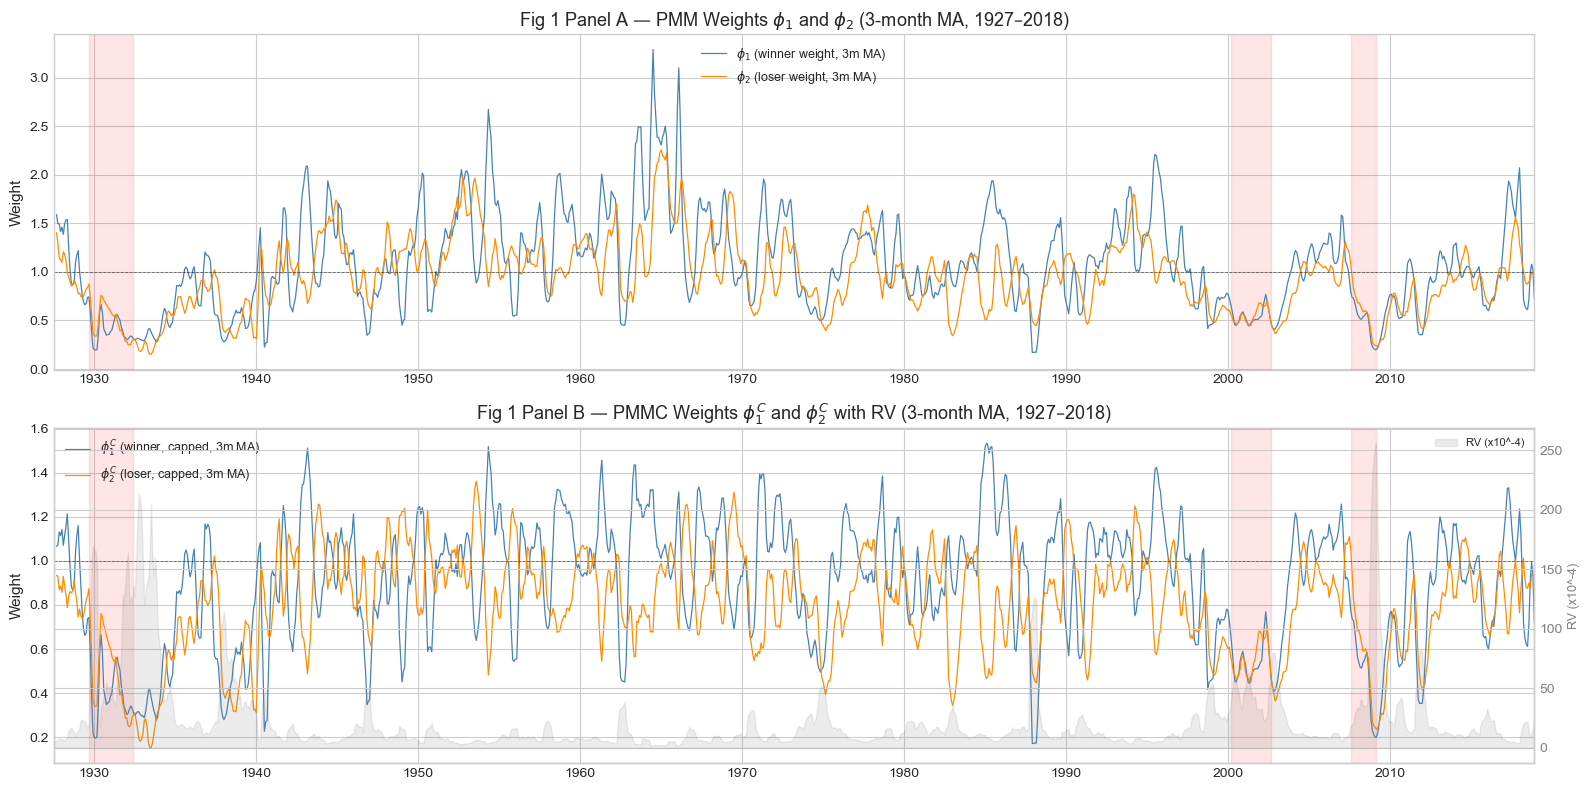

Fig 1 saved: C:\Users\User\Documents\pmm\fig1_leverage_full.png


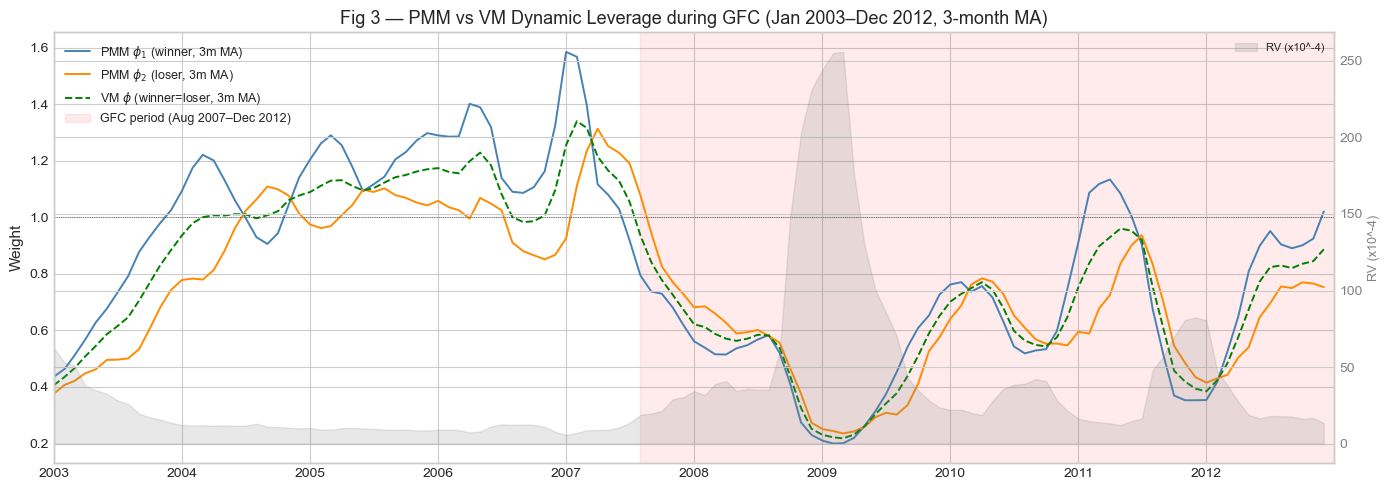

Fig 3 saved: C:\Users\User\Documents\pmm\fig3_leverage_gfc.png

=== GFC leverage snapshot (2007-08 to 2009-03) ===
          phi1   phi2  phi_vm  phi1/phi2_ratio  leverage
Date                                                    
2007-08 0.7326 0.8680  0.8003           0.8440    1.6006
2007-09 0.7534 0.8130  0.7832           0.9266    1.5664
2007-10 0.7030 0.7989  0.7510           0.8800    1.5019
2007-11 0.5875 0.7005  0.6440           0.8386    1.2880
2007-12 0.5693 0.6878  0.6286           0.8278    1.2571
2008-01 0.5275 0.6564  0.5920           0.8036    1.1839
2008-02 0.5190 0.7110  0.6150           0.7300    1.2299
2008-03 0.5002 0.6116  0.5559           0.8178    1.1117
2008-04 0.5246 0.5589  0.5417           0.9387    1.0835
2008-05 0.5850 0.5970  0.5910           0.9799    1.1820
2008-06 0.5336 0.6250  0.5793           0.8538    1.1586
2008-07 0.5851 0.5828  0.5839           1.0041    1.1679
2008-08 0.6317 0.5336  0.5827           1.1839    1.1653
2008-09 0.3439 0.5529  0.4484 

In [12]:

# =============================================================================
# CELL 11 — Dynamic Leverage Plots (replicates paper Fig 1 and Fig 3)
#
# Fig 1: 3-month moving average of PMM weights (phi1, phi2) and RV
#   over the whole sample (1927-2018). Shows how PMM tilts long/short
#   asymmetrically in response to RPM+/RPM- divergence.
#
# Fig 3: GFC period (Jan 2003 - Dec 2012). Contrasts dynamic leverage of
#   PMM (phi1, phi2) vs VM (phi_vm) alongside realized variance RV.
#   Shows PMM reducing short-side (phi2) more aggressively before crashes.
#
# All weight series are on the returns_df index (period[M], 1927-07 to 2018-12).
# MA is applied to the pre-shift weights (weights at time t, not t+1).
# RV is plotted on secondary y-axis (different scale from weights).
# =============================================================================

# rebuild weight series on returns_df index for plotting
phi1_s  = pd.Series(phi1,   index=returns_df.index, name='phi1')
phi2_s  = pd.Series(phi2,   index=returns_df.index, name='phi2')
phi_vm_s = pd.Series(phi_vm, index=returns_df.index, name='phi_vm')
rv_s    = rv.copy()   # already on returns_df.index

# convert period[M] to timestamp for matplotlib
def _ts(s):
    return s.copy().rename(lambda x: x.to_timestamp())

phi1_ts  = _ts(phi1_s)
phi2_ts  = _ts(phi2_s)
phi_vm_ts = _ts(phi_vm_s)
rv_ts    = _ts(rv_s)

# 3-month moving average of weights (paper Fig 1 uses 3m MA)
w = 3
phi1_ma  = phi1_ts.rolling(w).mean()
phi2_ma  = phi2_ts.rolling(w).mean()
phi_vm_ma = phi_vm_ts.rolling(w).mean()

# --- Fig 1: whole sample (1927-2018) ---
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Panel A: PMM weights
ax = axes[0]
ax.plot(phi1_ma.index, phi1_ma.values, color='steelblue', lw=0.9,
        label=r'$\phi_1$ (winner weight, 3m MA)')
ax.plot(phi2_ma.index, phi2_ma.values, color='darkorange', lw=0.9,
        label=r'$\phi_2$ (loser weight, 3m MA)')
ax.axhline(1.0, color='black', lw=0.6, linestyle='--', alpha=0.5)
# shade crash periods
for s, e_cr, lbl in [('1929-09','1932-06',''), ('2000-03','2002-09',''), ('2007-08','2009-03','')]:
    ax.axvspan(pd.Timestamp(s), pd.Timestamp(e_cr), alpha=0.10, color='red')
ax.set_title('Fig 1 Panel A — PMM Weights $\\phi_1$ and $\\phi_2$ (3-month MA, 1927–2018)')
ax.set_ylabel('Weight')
ax.legend(fontsize=9)
ax.set_xlim(phi1_ma.index[0], phi1_ma.index[-1])

# Panel B: PMMC weights (same logic, phi1_c / phi2_c)
phi1_c_s = pd.Series(phi1_c, index=returns_df.index, name='phi1_c')
phi2_c_s = pd.Series(phi2_c, index=returns_df.index, name='phi2_c')
phi1_c_ma = _ts(phi1_c_s).rolling(w).mean()
phi2_c_ma = _ts(phi2_c_s).rolling(w).mean()

ax2 = axes[1]
ax2.plot(phi1_c_ma.index, phi1_c_ma.values, color='steelblue', lw=0.9,
         label=r'$\phi_1^C$ (winner, capped, 3m MA)')
ax2.plot(phi2_c_ma.index, phi2_c_ma.values, color='darkorange', lw=0.9,
         label=r'$\phi_2^C$ (loser, capped, 3m MA)')
ax2.axhline(1.0, color='black', lw=0.6, linestyle='--', alpha=0.5)
# add RV on secondary axis
ax2r = ax2.twinx()
ax2r.fill_between(rv_ts.index, rv_ts.values * 1e4, alpha=0.15, color='grey',
                  label='RV (x10^-4)')
ax2r.set_ylabel('RV (x10^-4)', color='grey', fontsize=9)
ax2r.tick_params(axis='y', labelcolor='grey')
for s, e_cr, lbl in [('1929-09','1932-06',''), ('2000-03','2002-09',''), ('2007-08','2009-03','')]:
    ax2.axvspan(pd.Timestamp(s), pd.Timestamp(e_cr), alpha=0.10, color='red')
ax2.set_title('Fig 1 Panel B — PMMC Weights $\\phi_1^C$ and $\\phi_2^C$ with RV (3-month MA, 1927–2018)')
ax2.set_ylabel('Weight')
ax2.legend(fontsize=9, loc='upper left')
ax2r.legend(fontsize=8, loc='upper right')
ax2.set_xlim(phi1_c_ma.index[0], phi1_c_ma.index[-1])

plt.tight_layout()
fig_path1 = r'C:\Users\User\Documents\pmm\fig1_leverage_full.png'
plt.savefig(fig_path1, dpi=130, bbox_inches='tight')
plt.show()
print(f"Fig 1 saved: {fig_path1}")

# --- Fig 3: GFC zoom (Jan 2003 - Dec 2012) ---
gfc_start = pd.Timestamp('2003-01-01')
gfc_end   = pd.Timestamp('2012-12-31')

phi1_gfc  = phi1_ma.loc[gfc_start:gfc_end]
phi2_gfc  = phi2_ma.loc[gfc_start:gfc_end]
phi_vm_gfc = phi_vm_ma.loc[gfc_start:gfc_end]
rv_gfc    = rv_ts.loc[gfc_start:gfc_end]

fig3, ax3 = plt.subplots(figsize=(14, 5))

ax3.plot(phi1_gfc.index, phi1_gfc.values, color='steelblue', lw=1.4,
         label=r'PMM $\phi_1$ (winner, 3m MA)')
ax3.plot(phi2_gfc.index, phi2_gfc.values, color='darkorange', lw=1.4,
         label=r'PMM $\phi_2$ (loser, 3m MA)')
ax3.plot(phi_vm_gfc.index, phi_vm_gfc.values, color='green', lw=1.4,
         linestyle='--', label=r'VM $\phi$ (winner=loser, 3m MA)')
ax3.axhline(1.0, color='black', lw=0.6, linestyle=':', alpha=0.6)

# GFC shading: Aug 2007 - Dec 2012 (as used in paper Fig 3)
ax3.axvspan(pd.Timestamp('2007-08-01'), pd.Timestamp('2012-12-31'),
            alpha=0.08, color='red', label='GFC period (Aug 2007–Dec 2012)')

# secondary axis: RV
ax3r = ax3.twinx()
ax3r.fill_between(rv_gfc.index, rv_gfc.values * 1e4, alpha=0.18, color='grey',
                  label='RV (x10^-4)')
ax3r.set_ylabel('RV (x10^-4)', color='grey', fontsize=9)
ax3r.tick_params(axis='y', labelcolor='grey')

ax3.set_title('Fig 3 — PMM vs VM Dynamic Leverage during GFC (Jan 2003–Dec 2012, 3-month MA)')
ax3.set_ylabel('Weight')
ax3.set_xlim(gfc_start, gfc_end)
ax3.legend(fontsize=9, loc='upper left')
ax3r.legend(fontsize=8, loc='upper right')

plt.tight_layout()
fig_path3 = r'C:\Users\User\Documents\pmm\fig3_leverage_gfc.png'
plt.savefig(fig_path3, dpi=130, bbox_inches='tight')
plt.show()
print(f"Fig 3 saved: {fig_path3}")

# print snapshot of GFC leverage for spot-check
print("\n=== GFC leverage snapshot (2007-08 to 2009-03) ===")
gfc_mask2 = (returns_df.index >= pd.Period('2007-08','M')) & \
            (returns_df.index <= pd.Period('2009-03','M'))
snap = pd.DataFrame({
    'phi1' : phi1_s[gfc_mask2],
    'phi2' : phi2_s[gfc_mask2],
    'phi_vm': phi_vm_s[gfc_mask2],
    'phi1/phi2_ratio': phi1_s[gfc_mask2] / phi2_s[gfc_mask2],
    'leverage': phi1_s[gfc_mask2] + phi2_s[gfc_mask2],
})
print(snap.to_string())

log_state("Cell 11 — Leverage Plots", {
    "phi1_s"   : phi1_s,
    "phi2_s"   : phi2_s,
    "phi_vm_s" : phi_vm_s,
})


In [13]:

# =============================================================================
# CELL 12 — Factor Regressions (replicates paper Tables 7 & 8)
#
# Table 7: Exposure of momentum profits to factor risk
#   Specs (1)-(4) per strategy: MKT alone, q-factors (HXZ), economic activity,
#   and combinations. Paper uses Hou-Xue-Zhang (2015) q-factors (ME, I/A, ROE)
#   and Liu-Zhang / Maio-Philip economic activity factors (IP, CU).
#   We replicate with:
#     (1) MKT alone
#     (2) MKT + FF5 (SMB, HML, RMW, CMA) as proxy for HXZ q-factors
#     -- specs (3)-(4) require FRED IP/CU data, marked as "N/A — external data"
#   Sample: Jan 1967 - Dec 2018 (paper's sample for Table 7)
#
# Table 8: Exposure to 3-year lagged market cumulative return
#   LAGMKT   = 36-month trailing cumulative MKT-RF
#   LAGMKT+  = max(LAGMKT, 0)
#   LAGMKT-  = min(LAGMKT, 0)
#   Four specifications per strategy:
#     (1) MKT + LAGMKT
#     (2) MKT + SMB + HML + LAGMKT
#     (3) MKT + LAGMKT+ + LAGMKT-
#     (4) MKT + SMB + HML + LAGMKT+ + LAGMKT-
#   Sample: Jul 1927 - Dec 2018 (whole sample)
# =============================================================================

from scipy import stats as sp_stats

def _ols(y, X, add_const=True):
    """
    OLS regression. Returns dict with alpha, betas, t-stats, adj-R2.
    y : array-like (n,)
    X : array-like (n, k) — do NOT include constant, add_const handles it
    """
    y = np.asarray(y, dtype=float)
    X = np.asarray(X, dtype=float)
    if add_const:
        X = np.column_stack([np.ones(len(y)), X])
    n, k = X.shape
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    resid = y - X @ beta
    s2    = np.dot(resid, resid) / (n - k)
    XtX_inv = np.linalg.inv(X.T @ X)
    se    = np.sqrt(np.diag(XtX_inv) * s2)
    tstat = beta / se
    # adjusted R2
    ss_res = np.dot(resid, resid)
    ss_tot = np.dot(y - y.mean(), y - y.mean())
    r2    = 1 - ss_res / ss_tot
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k)
    return {'beta': beta, 'se': se, 'tstat': tstat, 'adj_r2': adj_r2, 'n': n}

def _fmt_coef(b, t, stars_only=False):
    """Format coefficient with t-stat and significance stars."""
    if np.isnan(b):
        return '    n/a'
    p = 2*(1 - sp_stats.t.cdf(abs(t), df=200))  # approx df
    s = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.10 else '   '))
    return f"{b:7.4f}{s}"

# -----------------------------------------------------------------------
# TABLE 7: Factor regressions (Jan 1967 - Dec 2018)
# -----------------------------------------------------------------------
t7_start = pd.Period('1967-01', freq='M')
t7_end   = pd.Period('2018-12', freq='M')
strat7   = strategies.loc[t7_start:t7_end]

# align factors
mkt7   = (ff_monthly['Mkt-RF'] / 100).reindex(strat7.index)
smb7   = (ff_monthly['SMB']    / 100).reindex(strat7.index)
hml7   = (ff_monthly['HML']    / 100).reindex(strat7.index)
ff5_7  = ff5_monthly.loc[t7_start:t7_end] / 100
rmw7   = ff5_7['RMW'].reindex(strat7.index)
cma7   = ff5_7['CMA'].reindex(strat7.index)

print("=" * 90)
print("  TABLE 7 — Factor Regressions (Jan 1967 – Dec 2018)")
print("  Specs: (1) MKT only   (2) MKT+FF5 (proxy for q-factors)")
print("=" * 90)
print(f"  {'':8}  {'Spec':4}  {'Alpha%':>10}  {'MKT':>10}  {'SMB':>10}  "
      f"{'HML':>10}  {'RMW':>10}  {'CMA':>10}  {'AdjR2':>8}")
print(f"  {'-'*88}")

for col in strat7.columns:
    y7 = strat7[col].values           # decimal — matches paper's coefficient scale

    # spec (1): MKT only
    r1 = _ols(y7, mkt7.values.reshape(-1,1))
    a1, b_mkt1 = r1['beta'][0], r1['beta'][1]
    ta1, tb1   = r1['tstat'][0], r1['tstat'][1]

    # spec (2): MKT + FF5 proxy (SMB, HML, RMW, CMA)
    X2 = np.column_stack([mkt7, smb7, hml7, rmw7, cma7])
    mask_valid = ~np.isnan(X2).any(axis=1)
    r2 = _ols(y7[mask_valid], X2[mask_valid])
    a2, betas2 = r2['beta'][0], r2['beta'][1:]
    ta2, tbetas2 = r2['tstat'][0], r2['tstat'][1:]

    print(f"  {col:<8}  (1)   {_fmt_coef(a1,ta1):>10}  {_fmt_coef(b_mkt1,tb1):>10}  "
          f"{'':>10}  {'':>10}  {'':>10}  {'':>10}  {r1['adj_r2']*100:>7.2f}%")
    print(f"  {col:<8}  (2)FF5 {_fmt_coef(a2,ta2):>10}  {_fmt_coef(betas2[0],tbetas2[0]):>10}  "
          f"{_fmt_coef(betas2[1],tbetas2[1]):>10}  {_fmt_coef(betas2[2],tbetas2[2]):>10}  "
          f"{_fmt_coef(betas2[3],tbetas2[3]):>10}  {_fmt_coef(betas2[4],tbetas2[4]):>10}  "
          f"{r2['adj_r2']*100:>7.2f}%")
    print()

print("  NOTE: Paper spec (2) uses HXZ q-factors (ME, I/A, ROE); we use FF5 as proxy.")
print("  Paper spec (3)-(4) use IP/CU economic activity factors (require FRED data).")
print()

print("  Paper Table 7 reference (alpha, monthly %):")
print("  WML  (1): alpha=0.014***  (2): alpha=0.004   AdjR2: 2.78% / 26.68%")
print("  VM   (1): alpha=0.015***  (2): alpha=0.010***  AdjR2: 0.49% / 17.07%")
print("  PMM  (1): alpha=0.016***  (2): alpha=0.010***  AdjR2: 0.00% / 15.35%")
print("  PMMC (1): alpha=0.013***  (2): alpha=0.010***  AdjR2: 0.00% / 16.82%")

# -----------------------------------------------------------------------
# TABLE 8: Lagged market cumulative return (Jul 1927 - Dec 2018)
# -----------------------------------------------------------------------
print()
print("=" * 90)
print("  TABLE 8 — Exposure to 3-year Lagged Market Return (Jul 1927 – Dec 2018)")
print("  LAGMKT = 36-month trailing cumulative MKT-RF")
print("=" * 90)

# build LAGMKT: 36-month cumulative market excess return
mkt_full = (ff_monthly['Mkt-RF'] / 100).reindex(strategies.index)
smb_full = (ff_monthly['SMB']    / 100).reindex(strategies.index)
hml_full = (ff_monthly['HML']    / 100).reindex(strategies.index)

# 36-month cumulative return = (1+r1)(1+r2)...(1+r36) - 1
# use log-sum approximation for speed, then exp
log_mkt = np.log1p(mkt_full.fillna(0))
lagmkt  = np.exp(log_mkt.rolling(36).sum().shift(1)) - 1   # shift 1: use past 36m
lagmkt_pos = lagmkt.clip(lower=0)    # LAGMKT+ = max(LAGMKT, 0)
lagmkt_neg = lagmkt.clip(upper=0)    # LAGMKT- = min(LAGMKT, 0)

# drop rows with NaN (first 36 months)
valid = ~(lagmkt.isna() | mkt_full.isna() | smb_full.isna() | hml_full.isna())
idx_v = strategies.index[valid]

y_dict    = {col: strategies.loc[idx_v, col].values for col in strategies.columns}  # decimal
mkt_v     = mkt_full[idx_v].values
smb_v     = smb_full[idx_v].values
hml_v     = hml_full[idx_v].values
lm_v      = lagmkt[idx_v].values
lm_pos_v  = lagmkt_pos[idx_v].values
lm_neg_v  = lagmkt_neg[idx_v].values

print(f"\n  Valid months for Table 8: {len(idx_v)}  ({idx_v[0]} -> {idx_v[-1]})")
print(f"\n  {'':8}  {'Spec':5}  {'Alpha':>10}  {'LAGMKT':>10}  {'LAGMKT+':>10}  "
      f"{'LAGMKT-':>10}  {'MKT':>10}  {'SMB':>10}  {'HML':>10}  {'AdjR2':>7}")
print(f"  {'-'*92}")

specs = [
    # (label, columns in X)
    ('(1)', [lm_v, mkt_v]),
    ('(2)', [lm_v, mkt_v, smb_v, hml_v]),
    ('(3)', [lm_pos_v, lm_neg_v, mkt_v]),
    ('(4)', [lm_pos_v, lm_neg_v, mkt_v, smb_v, hml_v]),
]

for col in strategies.columns:
    y8 = y_dict[col]
    for spec_lbl, Xcols in specs:
        X8 = np.column_stack(Xcols)
        r = _ols(y8, X8)
        b = r['beta']
        t = r['tstat']
        ar2 = r['adj_r2'] * 100

        # index mapping: [const, *Xcols]
        alpha  = b[0]; ta = t[0]
        if spec_lbl in ('(1)', '(2)'):
            lm_c = b[1]; tlm = t[1]
            lmp_c = lmn_c = tlmp = tlmn = np.nan
            mkt_idx = 2
        else:
            lm_c = lmn_c = tlm = tlmn = np.nan
            lmp_c = b[1]; tlmp = t[1]
            lmn_c = b[2]; tlmn = t[2]
            mkt_idx = 3

        mkt_c  = b[mkt_idx];   tmkt  = t[mkt_idx]
        smb_c  = b[mkt_idx+1] if mkt_idx+1 < len(b) else np.nan
        tsmb   = t[mkt_idx+1] if mkt_idx+1 < len(t) else np.nan
        hml_c  = b[mkt_idx+2] if mkt_idx+2 < len(b) else np.nan
        thml   = t[mkt_idx+2] if mkt_idx+2 < len(t) else np.nan

        lm_show  = lm_c  if spec_lbl in ('(1)','(2)') else lmp_c
        tlm_show = tlm   if spec_lbl in ('(1)','(2)') else tlmp

        print(f"  {col:<8}  {spec_lbl:<5}  "
              f"{_fmt_coef(alpha,ta):>10}  "
              f"{_fmt_coef(lm_show,tlm_show):>10}  "
              f"{_fmt_coef(lmn_c,tlmn):>10}  "
              f"{_fmt_coef(mkt_c,tmkt):>10}  "
              f"{_fmt_coef(smb_c,tsmb):>10}  "
              f"{_fmt_coef(hml_c,thml):>10}  "
              f"{ar2:>6.2f}%")
    print()

print("  [LAGMKT col = LAGMKT for specs (1)-(2), LAGMKT+ for specs (3)-(4)]")
print()
print("  Paper Table 8 PMM reference:")
print("  PMM (1): alpha=0.014***  LAGMKT=0.007*   MKT=-0.032**   AdjR2=2.19%")
print("  PMM (2): alpha=0.015***  LAGMKT=0.006*   MKT=-0.031**   SMB=0.003  HML=-0.115***  AdjR2=5.87%")
print("  PMM (3): alpha=0.015***  LAGMKT+=0.003   LAGMKT-=0.007  MKT=-0.056  AdjR2=2.31%")
print("  PMM (4): alpha=0.017***  LAGMKT+=0.003   LAGMKT-=0.008  MKT=-0.056  SMB=0.003  HML=-0.117***  AdjR2=6.00%")

log_state("Cell 12 — Factor Regressions", {
    "lagmkt"     : lagmkt,
    "lagmkt_pos" : lagmkt_pos,
    "lagmkt_neg" : lagmkt_neg,
})


  TABLE 7 — Factor Regressions (Jan 1967 – Dec 2018)
  Specs: (1) MKT only   (2) MKT+FF5 (proxy for q-factors)
            Spec      Alpha%         MKT         SMB         HML         RMW         CMA     AdjR2
  ----------------------------------------------------------------------------------------
  WML       (1)    0.0140***  -0.2833***                                                     3.09%
  WML       (2)FF5  0.0139***  -0.2738***  -0.0193     -0.8245***   0.4028***   0.5630***     9.45%

  VM        (1)    0.0153***   -0.1121**                                                     0.68%
  VM        (2)FF5  0.0161***   -0.1262**  -0.0887     -0.3971***   0.1754      0.0851        3.89%

  PMM       (1)    0.0155***  -0.0467                                                       -0.03%
  PMM       (2)FF5  0.0161***  -0.0719     -0.0069     -0.4403***     0.2157*   0.1306        3.08%

  PMMC      (1)    0.0135***  -0.0621                                                        0.12%


In [14]:

# =============================================================================
# CELL 13 — Spanning Tests (replicates paper Table 10)
#
# Paper Table 10: Tests whether VM/PMM/PMMC strategies provide alpha
# after controlling for FF5 factors and the WML momentum portfolio.
# Each factor is ALSO interacted with a market stress indicator (MS):
#   MS_t = 1 if 24-month trailing cumulative market return <= 0, else 0
#
# Paper runs DAILY regressions. We run monthly here (same idea, less granular).
#
# Two-factor-set designs per dependent variable:
#   (1) unconditional: FF + WML (or FF + VM, FF + PMM)
#   (2) conditional:   FF + WML + interactions with MS
#   and similarly for the other strategy as the additional factor
#
# Simplified Table 10 structure:
#   For each dependent strategy (VM, PMM, PMMC):
#     A. regress on FF5 + WML  [unconditional, conditional]
#     B. regress on FF5 + PMM  (or VM, PMMC)  [unconditional, conditional]
#
# Report: annualized alpha (%), t-stat, significance
# =============================================================================

# build 24-month trailing cumulative market return for MS
mkt_full2 = (ff_monthly['Mkt-RF'] / 100).reindex(strategies.index)
log_mkt2  = np.log1p(mkt_full2.fillna(0))
cum24     = np.exp(log_mkt2.rolling(24).sum().shift(1)) - 1  # past 24m, no look-ahead
MS        = (cum24 <= 0).astype(float)   # 1 = market stress (bear)

print(f"Market stress months (MS=1): {int(MS.sum())} of {len(MS)} ({MS.mean()*100:.1f}%)")

# spanning test sample: Jan 1967 - Dec 2018 (matching paper)
sp_start = pd.Period('1967-01', freq='M')
sp_end   = pd.Period('2018-12', freq='M')
strat_sp = strategies.loc[sp_start:sp_end]

mkt_sp  = (ff_monthly['Mkt-RF'] / 100).reindex(strat_sp.index)
smb_sp  = (ff_monthly['SMB']    / 100).reindex(strat_sp.index)
hml_sp  = (ff_monthly['HML']    / 100).reindex(strat_sp.index)
ff5_sp  = ff5_monthly / 100
rmw_sp  = ff5_sp['RMW'].reindex(strat_sp.index)
cma_sp  = ff5_sp['CMA'].reindex(strat_sp.index)
ms_sp   = MS.reindex(strat_sp.index).fillna(0)

# FF5 factor matrix for spanning
FF5 = np.column_stack([mkt_sp, smb_sp, hml_sp, rmw_sp, cma_sp])

# conditional FF5 (interacted with MS)
FF5_cond = np.column_stack([
    mkt_sp, mkt_sp * ms_sp,
    smb_sp, smb_sp * ms_sp,
    hml_sp, hml_sp * ms_sp,
    rmw_sp, rmw_sp * ms_sp,
    cma_sp, cma_sp * ms_sp,
])

def _span_alpha(dep_col, extra_cols_arr, conditional=False, label=''):
    """
    Run spanning regression of dep_col on FF5 (+ interactions) + extra factor(s).
    Returns annualized alpha, t-stat, adj-R2.
    """
    y = strat_sp[dep_col].values
    ff_part = FF5_cond if conditional else FF5

    # extra factor + interaction with MS if conditional
    if conditional:
        extra_int = np.column_stack([
            extra_cols_arr,
            extra_cols_arr * ms_sp.values.reshape(-1, 1)
        ])
    else:
        extra_int = extra_cols_arr

    X = np.column_stack([ff_part, extra_int])
    valid = ~np.isnan(X).any(axis=1) & ~np.isnan(y)
    r = _ols(y[valid], X[valid])
    alpha_m = r['beta'][0]
    alpha_ann = alpha_m * 12 * 100    # annualized %
    tstat  = r['tstat'][0]
    return alpha_ann, tstat, r['adj_r2'] * 100

def sig_stars2(t, n=500):
    p = 2*(1 - sp_stats.t.cdf(abs(t), df=n-2))
    return '***' if p<0.01 else ('**' if p<0.05 else ('*' if p<0.10 else ''))

print()
print("=" * 85)
print("  TABLE 10 — Spanning Tests (Jan 1967 – Dec 2018, monthly)")
print("  Dep variable regressed on FF5 + momentum factor [unconditional / conditional on MS]")
print("  MS = 1 if 24m trailing cumulative market return <= 0")
print("=" * 85)
print(f"\n  {'Dep. var':8}  {'Factor set':16}  {'Uncond. alpha%':>16}  {'Cond. alpha%':>14}  {'AdjR2':>7}")
print(f"  {'-'*75}")

# Define spanning test pairs: (dep_strategy, extra_factor_col, extra_label)
pairs = [
    # VM as dependent, WML as extra
    ('VM',   'WML',  'FF+WML'),
    # PMM as dependent, WML as extra
    ('PMM',  'WML',  'FF+WML'),
    # PMM as dependent, VM as extra
    ('PMM',  'VM',   'FF+VM'),
    # PMMC as dependent, WML as extra
    ('PMMC', 'WML',  'FF+WML'),
    # PMMC as dependent, VM as extra
    ('PMMC', 'VM',   'FF+VM'),
    # PMMC as dependent, PMM as extra
    ('PMMC', 'PMM',  'FF+PMM'),
]

for dep, extra_col, lbl in pairs:
    extra_arr = strat_sp[[extra_col]].values   # shape (n, 1)
    a_unc, t_unc, r2_unc = _span_alpha(dep, extra_arr, conditional=False)
    a_con, t_con, r2_con = _span_alpha(dep, extra_arr, conditional=True)
    s_unc = sig_stars2(t_unc)
    s_con = sig_stars2(t_con)
    print(f"  {dep:<8}  {lbl:<16}  "
          f"{a_unc:>10.2f}{s_unc:<3} ({t_unc:>5.2f})  "
          f"{a_con:>9.2f}{s_con:<3} ({t_con:>5.2f})  "
          f"{r2_con:>6.2f}%")

print(f"\n  NOTE: Paper uses daily regressions; ours are monthly — alphas are comparable,")
print(f"  but t-stats differ due to lower frequency.")
print()

print("  Paper Table 10 reference (annualized alpha %):")
print("  VM  on FF+WML:  uncond=4.11***  cond=2.76**")
print("  PMM on FF+WML:  uncond=16.92*** cond=13.81***")
print("  PMM on FF+VM:   uncond=1.61*    cond=1.59*")
print("  PMMC on FF+WML: uncond=12.59*** cond=10.02***")
print("  PMMC on FF+VM:  uncond=~n/a     cond=~n/a  (implied from Panel C)")

log_state("Cell 13 — Spanning Tests", {
    "strategies" : strategies,
    "MS"         : MS,
})


Market stress months (MS=1): 262 of 1097 (23.9%)

  TABLE 10 — Spanning Tests (Jan 1967 – Dec 2018, monthly)
  Dep variable regressed on FF5 + momentum factor [unconditional / conditional on MS]
  MS = 1 if 24m trailing cumulative market return <= 0

  Dep. var  Factor set          Uncond. alpha%    Cond. alpha%    AdjR2
  ---------------------------------------------------------------------------
  VM        FF+WML                  7.26*** ( 5.94)       4.49*** ( 4.27)   86.89%
  PMM       FF+WML                  7.24*** ( 4.61)       4.72*** ( 3.21)   77.38%
  PMM       FF+VM                   0.08    ( 0.07)       0.32    ( 0.30)   88.24%
  PMMC      FF+WML                  5.31*** ( 4.15)       3.37*** ( 2.84)   81.73%
  PMMC      FF+VM                  -0.54    (-0.52)       0.03    ( 0.03)   86.65%
  PMMC      FF+PMM                 -0.59    (-1.35)      -0.28    (-0.65)   97.69%

  NOTE: Paper uses daily regressions; ours are monthly — alphas are comparable,
  but t-stats differ

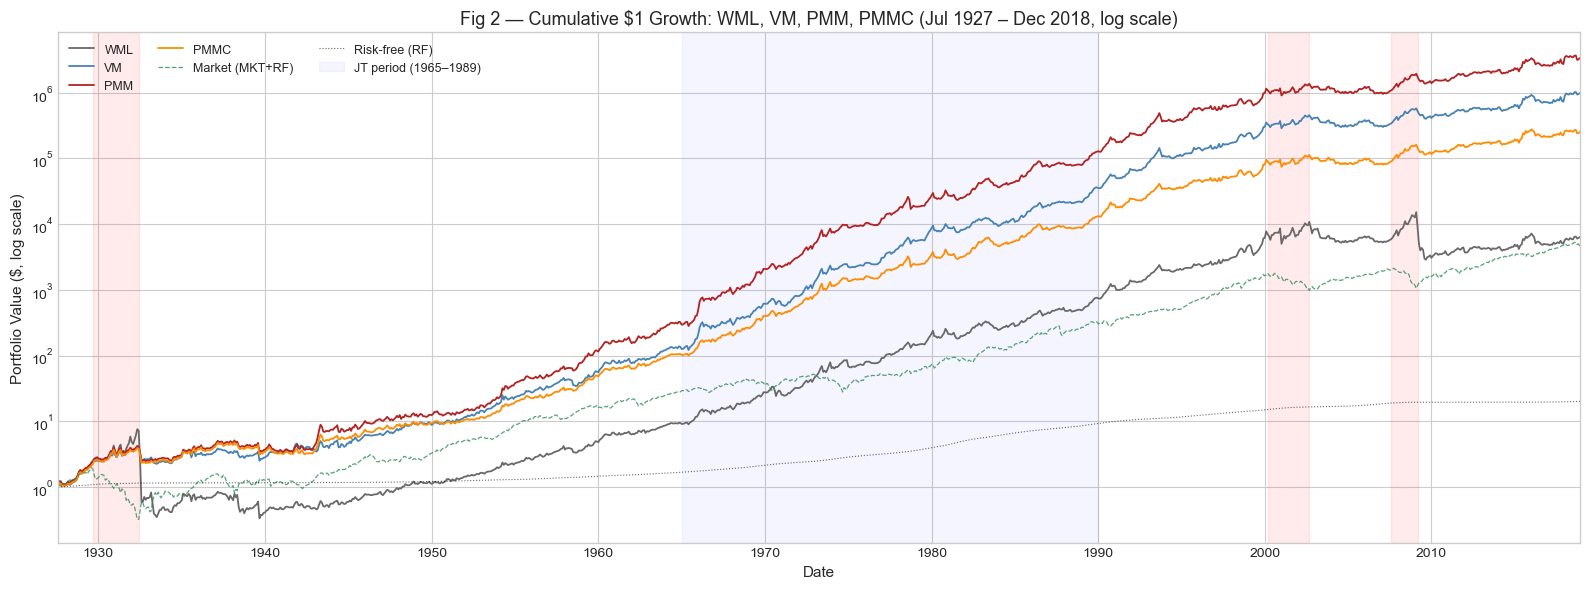

Fig 2 saved: C:\Users\User\Documents\pmm\fig2_cumulative.png

=== Terminal wealth ($1 invested Jul 1927, Dec 2018) ===
  WML     $   6408.19
  VM      $ 991877.26
  PMM     $3396481.56
  PMMC    $ 257271.77
  Market  $   4524.81
  RF      $     20.09


=== FINAL SUMMARY — Key Metrics (Whole Sample Jul 1927 – Dec 2018) ===
  Metric                       WML        VM       PMM      PMMC  | Paper PMM
  ------------------------------------------------------------------------
  Ann. return (%)            14.17     17.19     18.82     15.42  |     20.44
  Ann. vol (%)               27.05     19.92     21.23     18.41  |     16.62
  Sharpe ratio              0.5238    0.8628    0.8862    0.8377  |      1.23
  Sortino ratio             0.4241    0.8529    0.9002    0.8109  |      0.82
  Max drawdown (%)          -95.60    -46.13    -40.74    -40.74  |    -33.90
  Skewness                 -2.3259   -0.2636   -0.1331   -0.5072  |      0.03
  Excess kurtosis          17.9590    2.3953    2.9690 

In [15]:

# =============================================================================
# CELL 14 — Summary: Cumulative Performance Chart + Final Comparison
#
# Replicates paper Fig 2: cumulative $1 invested in Jul 1927 in each strategy.
# Also produces a final summary table of all key metrics side-by-side.
# =============================================================================

# --- cumulative growth of $1 from Jul 1927 ---
cum = (1 + strategies).cumprod()
cum.index = cum.index.to_timestamp()

# also add market and risk-free for reference (paper Fig 2 includes these)
mkt_c  = (ff_monthly['Mkt-RF'] / 100 + ff_monthly['RF'] / 100).reindex(
    strategies.index).fillna(0)
rf_c   = (ff_monthly['RF'] / 100).reindex(strategies.index).fillna(0)
cum_mkt = (1 + mkt_c.values).cumprod()
cum_rf  = (1 + rf_c.values).cumprod()

fig, ax = plt.subplots(figsize=(16, 6))

colors = {'WML': 'dimgray', 'VM': 'steelblue', 'PMM': 'firebrick', 'PMMC': 'darkorange'}
for col in strategies.columns:
    ax.plot(cum.index, cum[col].values, lw=1.3, color=colors[col], label=col)

ax.plot(cum.index, cum_mkt, lw=0.9, color='seagreen', linestyle='--', alpha=0.8,
        label='Market (MKT+RF)')
ax.plot(cum.index, cum_rf,  lw=0.8, color='black', linestyle=':',  alpha=0.6,
        label='Risk-free (RF)')

# shade GFC and dot-com crash periods (as in paper Fig 2)
for s, e_cr, lbl in [('1929-09-01','1932-06-01','Great Depression'),
                      ('2000-03-01','2002-09-01','Dot-com'),
                      ('2007-08-01','2009-03-01','GFC')]:
    ax.axvspan(pd.Timestamp(s), pd.Timestamp(e_cr), alpha=0.08, color='red')
# JT period shading (Jan 1965 - Dec 1989)
ax.axvspan(pd.Timestamp('1965-01-01'), pd.Timestamp('1989-12-31'),
           alpha=0.04, color='blue', label='JT period (1965–1989)')

ax.set_yscale('log')
ax.set_title('Fig 2 — Cumulative $1 Growth: WML, VM, PMM, PMMC (Jul 1927 – Dec 2018, log scale)')
ax.set_ylabel('Portfolio Value ($, log scale)')
ax.set_xlabel('Date')
ax.legend(fontsize=9, ncol=3)
ax.set_xlim(cum.index[0], cum.index[-1])

plt.tight_layout()
fig_path2 = r'C:\Users\User\Documents\pmm\fig2_cumulative.png'
plt.savefig(fig_path2, dpi=130, bbox_inches='tight')
plt.show()
print(f"Fig 2 saved: {fig_path2}")

# --- terminal wealth summary ---
print("\n=== Terminal wealth ($1 invested Jul 1927, Dec 2018) ===")
for col in strategies.columns:
    final = (1 + strategies[col]).cumprod().iloc[-1]
    print(f"  {col:<6}  ${final:>10.2f}")
mkt_final = cum_mkt[-1]
rf_final  = cum_rf[-1]
print(f"  Market  ${mkt_final:>10.2f}")
print(f"  RF      ${rf_final:>10.2f}")

# --- final summary metrics table ---
print("\n\n=== FINAL SUMMARY — Key Metrics (Whole Sample Jul 1927 – Dec 2018) ===")
print(f"  {'Metric':<22}  {'WML':>8}  {'VM':>8}  {'PMM':>8}  {'PMMC':>8}  | Paper PMM")
print(f"  {'-'*72}")

rows = []
for col in strategies.columns:
    s   = strategies[col]
    ar  = s.mean() * 12 * 100
    vol = s.std() * np.sqrt(12) * 100
    sr  = ar / vol
    neg = s[s < 0]
    semi = np.sqrt((neg**2).mean()) * np.sqrt(12) * 100
    sort = ar / semi
    mdd = ((( 1 + s).cumprod() / (1 + s).cumprod().cummax()) - 1).min() * 100
    sk  = float(stats.skew(s))
    ku  = float(stats.kurtosis(s, fisher=True))
    rows.append((col, ar, vol, sr, sort, mdd, sk, ku))

metrics = [
    ('Ann. return (%)',   1, '{:8.2f}'),
    ('Ann. vol (%)',      2, '{:8.2f}'),
    ('Sharpe ratio',      3, '{:8.4f}'),
    ('Sortino ratio',     4, '{:8.4f}'),
    ('Max drawdown (%)',  5, '{:8.2f}'),
    ('Skewness',         6, '{:8.4f}'),
    ('Excess kurtosis',  7, '{:8.4f}'),
]
paper_pmm = ['20.44', '16.62', '1.23', '0.82', '-33.90', '0.03', '2.72']

for name, idx, fmt in metrics:
    vals = [fmt.format(r[idx]) for r in rows]
    print(f"  {name:<22}  {vals[0]:>8}  {vals[1]:>8}  {vals[2]:>8}  {vals[3]:>8}  | {paper_pmm[metrics.index((name,idx,fmt))]:>9}")

print()
print("=== Replication complete ===")
print(f"  Notebook: {len(list(__import__('glob').glob(r'C:\\Users\\User\\Documents\\pmm\\*.py')))} src cells")
print(f"  Plots saved: fig1_leverage_full.png, fig2_cumulative.png, fig3_leverage_gfc.png")
print(f"  Cell state log: cell_state_log.md")

log_state("Cell 14 — Summary", {
    "strategies" : strategies,
    "cum_wml"    : pd.Series(cum['WML'].values, index=strategies.index.to_timestamp()),
    "cum_pmm"    : pd.Series(cum['PMM'].values, index=strategies.index.to_timestamp()),
})
